# Visualizaciones OLAP — Data Warehouse Transfermarkt
### Big Five: La Liga · Premier League · Serie A · Bundesliga · Ligue 1
---
Notebook de visualización de las 10 consultas OLAP definidas en `consultas_olap.sql`, ejecutadas sobre el esquema en constelación Kimball cargado en PostgreSQL 18.  
Cada sección corresponde a una operación OLAP distinta: **Slice, Dice, Roll-Up, Drill-Down, Pivot y Window Functions**.

Las visualizaciones siguen el **orden numérico de las consultas** del archivo SQL: de la **9.1** (ranking de goleadores) a la **12.4** (partidos más espectaculares).

| Nº | Consulta | Operación OLAP | Visualización |
|---|---|---|---|
| 1 | 9.1 | WINDOW · ROW_NUMBER | Top 25 goleadores históricos |
| 2 | 9.4 | SLICE · CASE WHEN | Factor campo — ventaja local |
| 3 | 9.5 | DRILL-DOWN · ROW_NUMBER | Pichichi por liga y temporada |
| 4 | 9.6 | DICE · CTEs · FULL OUTER JOIN | Balance gastos/ingresos por club |
| 5 | 9.7 | SLICE · CASE WHEN franjas | Goles por franja de minuto |
| 6 | 9.9 | ROLL-UP · LAG | Inflación del mercado de fichajes |
| 7 | 9.10 | DICE · 3 CTEs | Radar Chart KPI Big Five |
| 8 | 12.2 | DICE · NTILE Window | Inversión en fichajes vs victorias |
| 9 | 12.3 | ROLL-UP · AVG OVER PARTITION | Temporada más goleadora por liga |
| 10 | 12.4 | DICE · ROW_NUMBER | Top 20 partidos más espectaculares |

**Stack:** `psycopg2` · `pandas` · `matplotlib` · `seaborn`  


## 0. Setup y Conexión a la Base de Datos

In [1]:
# ── Instalación de dependencias (ejecuta esta celda solo la primera vez) ──────
# Si ya tienes los paquetes instalados puedes saltarla.
import subprocess, sys

paquetes = ['psycopg2-binary', 'pandas', 'matplotlib', 'seaborn', 'numpy']

for pkg in paquetes:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        # Muestra solo la última línea (Already satisfied / Successfully installed)
        linea = [l for l in result.stdout.strip().splitlines() if l]
        print(f"  ✓ {pkg}: {linea[-1] if linea else 'OK'}")
    else:
        print(f"  ✗ {pkg}: ERROR")
        print(result.stderr[-300:])

print("\n✅ Listo — puedes ejecutar el resto del notebook")

  ✓ psycopg2-binary: Requirement already satisfied: psycopg2-binary in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (2.9.11)
  ✓ pandas: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.8.2->pandas) (1.17.0)
  ✓ matplotlib: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.7->matplotlib) (1.17.0)
  ✓ seaborn: Requirement already satisfied: six>=1.5 in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (from python-dateutil>=2.7->matplotlib!=3.6.1,>=3.4->seaborn) (1.17.0)
  ✓ numpy: Requirement already satisfied: numpy in c:\users\manuc\appdata\local\programs\python\python313\lib\site-packages (2.2.5)

✅ Listo — puedes ejecutar el resto del notebook


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import psycopg2
from psycopg2.extras import RealDictCursor
import os
import getpass

# ── Estilo global ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'font.family': 'DejaVu Sans',
})
sns.set_theme(style='whitegrid', palette='muted')

# ── Paleta de ligas — nombres exactos de la BD ───────────────────────────────
LIGA_COLORS = {
    'laliga':          '#e74c3c',
    'premier-league':  '#3498db',
    'serie-a':         '#2ecc71',
    'bundesliga':      '#f39c12',
    'ligue-1':         '#9b59b6',
}
# Etiquetas legibles para mostrar en gráficos
LIGA_LABELS = {
    'laliga':          'La Liga',
    'premier-league':  'Premier League',
    'serie-a':         'Serie A',
    'bundesliga':      'Bundesliga',
    'ligue-1':         'Ligue 1',
}
LIGA_ORDER = ['laliga', 'premier-league', 'serie-a', 'bundesliga', 'ligue-1']

# ── Conexión ─────────────────────────────────────────────────────────────────
_pwd = getpass.getpass('🔐 Contraseña de PostgreSQL (postgres@localhost): ')

DB_PARAMS = dict(
    host     = 'localhost',
    port     = 5432,
    dbname   = 'football_dwh',
    user     = 'postgres',
    password = _pwd,
)

def get_conn():
    return psycopg2.connect(**DB_PARAMS)

def run_query(sql: str) -> pd.DataFrame:
    """Ejecuta una consulta SQL y devuelve un DataFrame de pandas."""
    with get_conn() as conn:
        with conn.cursor(cursor_factory=RealDictCursor) as cur:
            cur.execute("SET search_path TO dwh;")
            cur.execute(sql)
            rows = cur.fetchall()
    return pd.DataFrame([dict(r) for r in rows])

# ── Carpeta de exportación ───────────────────────────────────────────────────
EXPORT_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'graficos')
os.makedirs(EXPORT_DIR, exist_ok=True)

def save_fig(name: str):
    path = os.path.join(EXPORT_DIR, name)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    print(f"  ✓ Guardado: {path}")

# ── Test de conexión ─────────────────────────────────────────────────────────
try:
    df_test = run_query("SELECT COUNT(*) AS n FROM dwh.fact_games;")
    print(f"✅ Conexión OK — fact_games: {df_test['n'].iloc[0]:,} registros")
except Exception as e:
    print(f"❌ Error: {e}")
    print("   Verifica que PostgreSQL esté corriendo y la contraseña sea correcta.")

✅ Conexión OK — fact_games: 58,495 registros


---
## 1. WINDOW FUNCTION — Top 25 goleadores históricos de las Big Five
**Consulta 9.1** · Tablas: `fact_appearances`, `dim_players`, `dim_clubs`, `dim_competitions`

### ¿Qué hace la consulta?
Agrupa **todas las apariciones** de `fact_appearances` por jugador, sin ningún filtro de temporada, acumulando goles a lo largo de toda la historia del dataset. `ROW_NUMBER() OVER (ORDER BY SUM(fa.goals) DESC)` asigna un ranking único y sin empates. Además de los goles, calcula la métrica de eficiencia **goles por 90 minutos** (`SUM(goals)*90 / NULLIF(SUM(minutes_played),0)`) y `STRING_AGG` para concatenar todas las ligas y clubes en los que jugó cada jugador.

- **Filtro:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` — solo las Big Five; `HAVING SUM(goals) > 0`
- **Window:** `ROW_NUMBER()` aplicado sobre el agregado global (no por temporada ni por liga)
- **LIMIT 25:** extrae únicamente los 25 mejores
- **`NULLIF`:** evita división por cero en el cálculo de goles/90 min

### ¿Cómo se visualiza?
Se genera un **gráfico de barras horizontales** con `matplotlib`, donde cada barra representa un jugador ordenado de mayor a menor número de goles (eje Y invertido). El **color de cada barra** se asigna según la posición del jugador usando el diccionario `POS_COLORS` (Ataque=rojo, Centrocampismo=azul, Defensa=verde, Portero=naranja). El número de goles totales se anota en texto al final de cada barra.

Sobre el mismo gráfico se añade un **segundo eje X superior** (`ax.twiny()`) con un scatter de **rombos (◆)** que representan los goles por 90 minutos de cada jugador, permitiendo comparar eficiencia real frente a volumen bruto. La leyenda identifica las posiciones por color.

**Operación OLAP:** `WINDOW ROW_NUMBER` — ranking global acumulado histórico


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_01_top25_goleadores.png


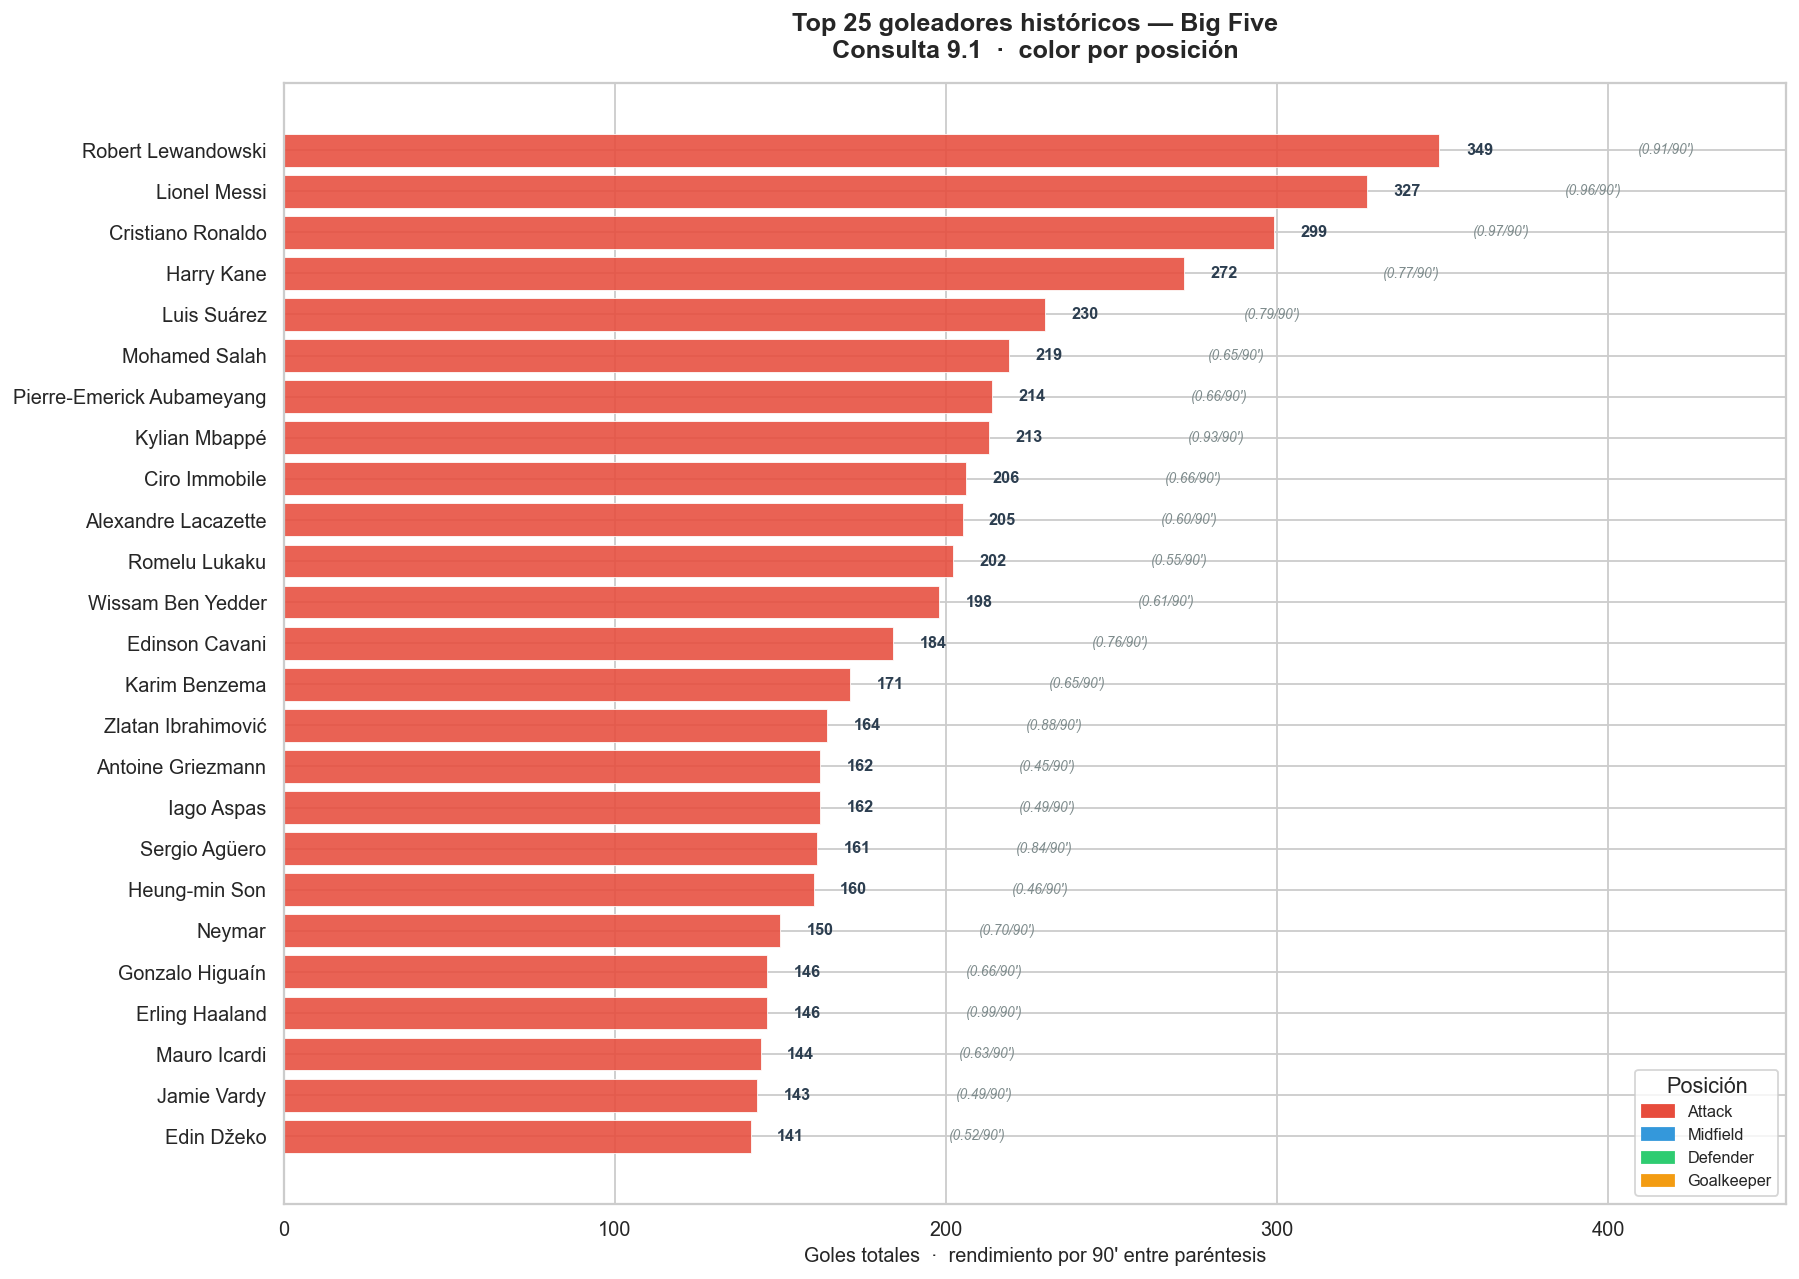

 ranking                   jugador posicion  goles  asistencias  partidos  goles_por_partido  goles_por_90min
       1        Robert Lewandowski   Attack    349           78       415               0.84             0.91
       2              Lionel Messi   Attack    327          165       364               0.90             0.96
       3         Cristiano Ronaldo   Attack    299           80       329               0.91             0.97
       4                Harry Kane   Attack    272           67       378               0.72             0.77
       5               Luis Suárez   Attack    230          110       324               0.71             0.79
       6             Mohamed Salah   Attack    219          112       375               0.58             0.65
       7 Pierre-Emerick Aubameyang   Attack    214           59       376               0.57             0.66
       8             Kylian Mbappé   Attack    213           77       274               0.78             0.93
       9  

In [45]:
# ── Consulta 9.1 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
SQL_TOP25 = """
SELECT
    ROW_NUMBER() OVER (ORDER BY SUM(fa.goals) DESC) AS ranking,
    p.name                                          AS jugador,
    p.position                                      AS posicion,
    p.country_of_citizenship                        AS nacionalidad,
    STRING_AGG(DISTINCT comp.name, ', ')            AS ligas,
    STRING_AGG(DISTINCT c.name, ', ')               AS clubes,
    SUM(fa.goals)                                   AS goles,
    SUM(fa.assists)                                 AS asistencias,
    SUM(fa.goals + fa.assists)                      AS participaciones_gol,
    COUNT(DISTINCT fa.game_id)                      AS partidos,
    ROUND(SUM(fa.goals)::NUMERIC / NULLIF(COUNT(DISTINCT fa.game_id), 0), 2)
                                                    AS goles_por_partido,
    SUM(fa.minutes_played)                          AS minutos_totales,
    ROUND(SUM(fa.goals)::NUMERIC * 90 / NULLIF(SUM(fa.minutes_played), 0), 2)
                                                    AS goles_por_90min
FROM dwh.fact_appearances fa
    INNER JOIN dwh.dim_players p         ON fa.player_id     = p.player_id
    INNER JOIN dwh.dim_clubs c           ON fa.club_id       = c.club_id
    INNER JOIN dwh.dim_competitions comp ON fa.competition_id = comp.competition_id
WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
  AND p.player_id != -1
GROUP BY p.name, p.position, p.country_of_citizenship
HAVING SUM(fa.goals) > 0
ORDER BY goles DESC
LIMIT 25;
"""

df_top25 = run_query(SQL_TOP25)
for col in ['goles', 'asistencias', 'partidos', 'participaciones_gol', 'minutos_totales']:
    df_top25[col] = pd.to_numeric(df_top25[col], errors='coerce').fillna(0).astype(int)
df_top25['goles_por_90min']  = pd.to_numeric(df_top25['goles_por_90min'],  errors='coerce')
df_top25['goles_por_partido'] = pd.to_numeric(df_top25['goles_por_partido'], errors='coerce')

# Colores por posición
POS_COLORS = {
    'Attack':     '#e74c3c',
    'Midfield':   '#3498db',
    'Defender':   '#2ecc71',
    'Goalkeeper': '#f39c12',
}
bar_colors = [POS_COLORS.get(p, '#95a5a6') for p in df_top25['posicion']]

fig, ax1 = plt.subplots(figsize=(14, 10))
bars = ax1.barh(df_top25['jugador'], df_top25['goles'],
                color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.88)

# Anotar goles totales + goles/90' en la misma línea, sin segundo eje
for bar, val, g90 in zip(bars, df_top25['goles'], df_top25['goles_por_90min']):
    x_end = bar.get_width()
    y_ctr = bar.get_y() + bar.get_height() / 2
    ax1.text(x_end + 8, y_ctr, str(int(val)),
             va='center', fontsize=9, fontweight='bold', color='#2c3e50')
    if pd.notna(g90):
        ax1.text(x_end + 60, y_ctr, f"({g90:.2f}/90')",
                 va='center', fontsize=7.5, color='#7f8c8d', style='italic')

ax1.invert_yaxis()
ax1.set_xlabel("Goles totales  ·  rendimiento por 90' entre paréntesis", fontsize=11)
ax1.set_title(
    'Top 25 goleadores históricos — Big Five\n'
    'Consulta 9.1  ·  color por posición',
    fontsize=14, fontweight='bold', pad=14,
)
ax1.set_xlim(0, df_top25['goles'].max() * 1.30)

legend_handles = [mpatches.Patch(color=c, label=p) for p, c in POS_COLORS.items()]
ax1.legend(handles=legend_handles, title='Posición', loc='lower right', fontsize=9)

plt.tight_layout()
save_fig('viz_01_top25_goleadores.png')
plt.show()

print(df_top25[['ranking', 'jugador', 'posicion', 'goles', 'asistencias',
                'partidos', 'goles_por_partido', 'goles_por_90min']].to_string(index=False))


---
## 2. SLICE + CASE WHEN — Factor campo: ¿existe ventaja de jugar en casa?
**Consulta 9.4** · Tablas: `fact_games`, `dim_competitions`

### ¿Qué hace la consulta?
Realiza un **SLICE** sobre `fact_games` filtrando las 5 ligas y usa bloques `CASE WHEN` para **pivotar condicionalmente** los resultados: una columna para victorias locales, otra para empates y otra para victorias visitantes, calculando el porcentaje de cada tipo sobre el total de partidos de esa liga (`SUM(CASE) / COUNT(*)`). Adicionalmente extrae `AVG(home_club_goals)` y `AVG(away_club_goals)` para la tabla comparativa. Los resultados se ordenan por `pct_victoria_local DESC` para identificar la liga con mayor ventaja de campo.

- **Filtro:** todos los años disponibles del dataset, solo las Big Five
- **Pivot condicional:** tres columnas derivadas de `CASE WHEN` sobre `is_home_win`, `is_draw`, `is_away_win`
- **Sin filtro temporal:** los porcentajes reflejan el comportamiento acumulado histórico de cada liga

### ¿Cómo se visualiza?
La figura se divide en dos paneles. El **panel izquierdo** muestra un **gráfico de barras apiladas al 100%** con una barra por liga, dividida en tres segmentos: verde (victoria local), gris (empate) y rojo (victoria visitante). El porcentaje se anota en texto dentro de cada segmento si supera el 4% de ancho. Las ligas aparecen en el eje Y, ordenadas de mayor a menor ventaja local.

El **panel derecho** es una **tabla de matplotlib** con los promedios de goles local y visitante por partido para cada liga, con cabecera oscura y filas alternas coloreadas. Las claves lowercase de `comp.name` se traducen a nombres legibles antes de mostrarlas, usando el diccionario `LIGA_LABELS`.

**Operación OLAP:** `SLICE` (Big Five, todos los años) + pivotado condicional `CASE WHEN`


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_02_factor_campo.png


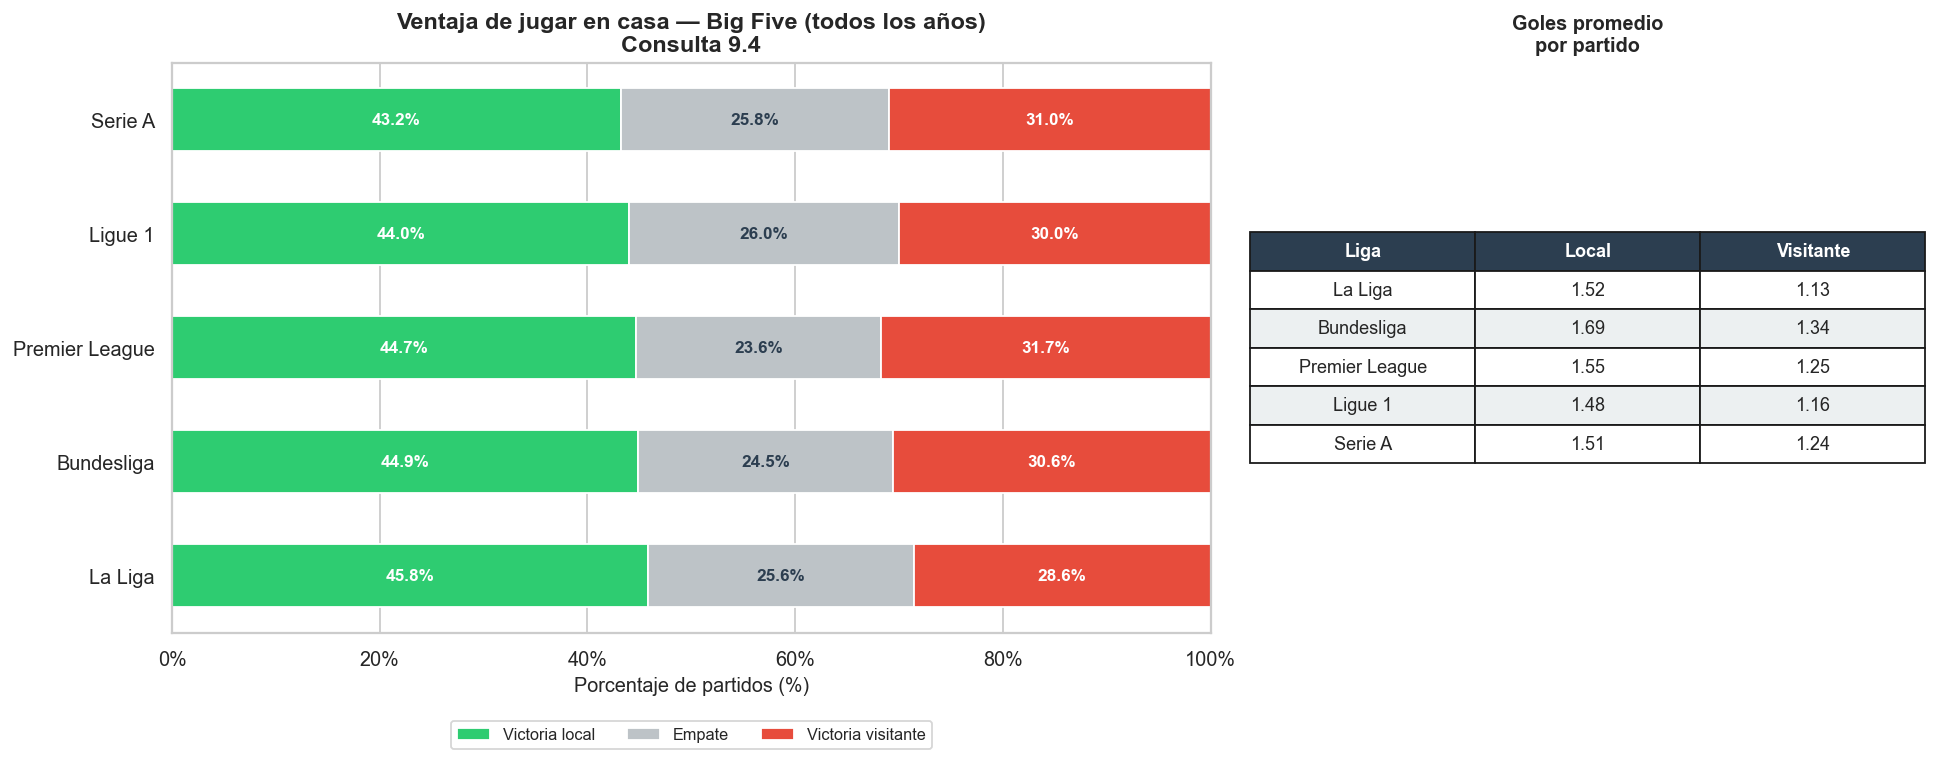

    liga_label  partidos_totales  victorias_local  empates  victorias_visitante  pct_victoria_local  pct_empate  pct_victoria_visitante
       La Liga              4859             2226     1242                 1391                45.8        25.6                    28.6
    Bundesliga              3924             1761      961                 1202                44.9        24.5                    30.6
Premier League              4869             2178     1149                 1542                44.7        23.6                    31.7
       Ligue 1              4637             2038     1206                 1393                44.0        26.0                    30.0
       Serie A              4870             2104     1256                 1510                43.2        25.8                    31.0


In [52]:

# ── Consulta 9.4 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
SQL_CAMPO = """
SELECT
    comp.name                                       AS liga,
    COUNT(*)                                        AS partidos_totales,
    SUM(CASE WHEN fg.is_home_win THEN 1 ELSE 0 END) AS victorias_local,
    SUM(CASE WHEN fg.is_draw THEN 1 ELSE 0 END)     AS empates,
    SUM(CASE WHEN fg.is_away_win THEN 1 ELSE 0 END) AS victorias_visitante,
    ROUND(100.0 * SUM(CASE WHEN fg.is_home_win THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                    AS pct_victoria_local,
    ROUND(100.0 * SUM(CASE WHEN fg.is_draw THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                    AS pct_empate,
    ROUND(100.0 * SUM(CASE WHEN fg.is_away_win THEN 1 ELSE 0 END) / COUNT(*), 1)
                                                    AS pct_victoria_visitante,
    ROUND(AVG(fg.home_club_goals), 2)               AS goles_local_promedio,
    ROUND(AVG(fg.away_club_goals), 2)               AS goles_visitante_promedio
FROM dwh.fact_games fg
    INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
GROUP BY comp.name
ORDER BY pct_victoria_local DESC;
"""

df_campo = run_query(SQL_CAMPO)
for col in ['pct_victoria_local', 'pct_empate', 'pct_victoria_visitante',
            'goles_local_promedio', 'goles_visitante_promedio',
            'victorias_local', 'empates', 'victorias_visitante', 'partidos_totales']:
    df_campo[col] = pd.to_numeric(df_campo[col], errors='coerce')

# comp.name devuelve claves lowercase → mapear a nombres legibles para el eje
df_campo['liga_label'] = df_campo['liga'].map(LIGA_LABELS).fillna(df_campo['liga'])

fig, (ax_main, ax_table) = plt.subplots(1, 2, figsize=(15, 6),
                                         gridspec_kw={'width_ratios': [2, 1]})
fig.subplots_adjust(bottom=0.18)   # espacio extra abajo para la leyenda

ligas  = df_campo['liga_label']
local  = df_campo['pct_victoria_local'].values
empate = df_campo['pct_empate'].values
visita = df_campo['pct_victoria_visitante'].values

y      = np.arange(len(ligas))
height = 0.55

b1 = ax_main.barh(y, local,  height=height, label='Victoria local',    color='#2ecc71')
b2 = ax_main.barh(y, empate, height=height, label='Empate',            color='#bdc3c7', left=local)
b3 = ax_main.barh(y, visita, height=height, label='Victoria visitante', color='#e74c3c',
                  left=local + empate)

for i, (vl, ve, vv) in enumerate(zip(local, empate, visita)):
    if vl > 4:
        ax_main.text(vl / 2,       i, f'{vl:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='white', fontweight='bold')
    if ve > 4:
        ax_main.text(vl + ve / 2,  i, f'{ve:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='#2c3e50', fontweight='bold')
    if vv > 4:
        ax_main.text(vl + ve + vv / 2, i, f'{vv:.1f}%', ha='center', va='center',
                     fontsize=9.5, color='white', fontweight='bold')

ax_main.set_yticks(y)
ax_main.set_yticklabels(ligas, fontsize=11)
ax_main.set_xlim(0, 100)
ax_main.set_xlabel('Porcentaje de partidos (%)', fontsize=11)
ax_main.set_title(
    'Ventaja de jugar en casa — Big Five (todos los años)\n'
    'Consulta 9.4',
    fontsize=13, fontweight='bold',
)
# Leyenda FUERA del área de barras: debajo del gráfico, centrada
ax_main.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14),
               ncol=3, fontsize=9, frameon=True)
ax_main.xaxis.set_major_formatter(mticker.PercentFormatter())

ax_table.axis('off')
tabla_data = [['Liga', 'Local', 'Visitante']] + [
    [row['liga_label'][:14], f"{row['goles_local_promedio']:.2f}",
     f"{row['goles_visitante_promedio']:.2f}"]
    for _, row in df_campo.iterrows()
]
tbl = ax_table.table(cellText=tabla_data[1:], colLabels=tabla_data[0],
                     loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.3, 1.7)
for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif row_idx % 2 == 0:
        cell.set_facecolor('#ecf0f1')
ax_table.set_title('Goles promedio\npor partido', fontsize=11, fontweight='bold', pad=6)

plt.tight_layout()
save_fig('viz_02_factor_campo.png')
plt.show()

print(df_campo[['liga_label', 'partidos_totales', 'victorias_local', 'empates',
                'victorias_visitante', 'pct_victoria_local', 'pct_empate',
                'pct_victoria_visitante']].to_string(index=False))


---
## 3. DRILL-DOWN + RANK — Pichichi por temporada y liga (2015–2024)
**Consulta 9.5** · Tablas: `fact_appearances`, `dim_players`, `dim_clubs`, `dim_date`, `dim_competitions`

### ¿Qué hace la consulta?
Ejecuta un **Drill-Down** descendiendo desde el nivel liga → temporada → jugador. Para cada combinación (liga, temporada) suma los goles de cada jugador y aplica `RANK() OVER (PARTITION BY comp.name, season_start_year ORDER BY SUM(goals) DESC)` para identificar al máximo goleador de cada liga en cada temporada. La subconsulta exterior filtra con `WHERE rk = 1`. `STRING_AGG` concatena los clubes por si el jugador cambió de equipo durante la temporada.

- **Ventana:** `PARTITION BY comp.name, season_start_year` — un ranking independiente por cada (liga, temporada)
- **`RANK` en lugar de `ROW_NUMBER`:** permite empates; si dos jugadores tienen los mismos goles, ambos reciben `rk = 1`
- **Filtro temporal:** `season_start_year BETWEEN 2015 AND 2024`

### ¿Cómo se visualiza?
En Python se aplica `drop_duplicates(subset=['liga', 'temporada'], keep='first')` **antes del pivot** para resolver posibles empates que `RANK` puede generar (dos filas con `rk=1` para la misma liga y temporada romperían `df.pivot()`). Se mantiene la primera fila, que corresponde al primero en orden alfabético.

Los datos se transforman con `df.pivot()` para obtener una matriz filas=temporada × columnas=liga, que se pasa a `seaborn.heatmap` con la paleta `YlOrRd` (amarillo = pocos goles, rojo = muchos). Cada celda se anota con `"{Apellido}\n(N goles)"` usando el apellido extraído del nombre completo. Las columnas se ordenan explícitamente según `LIGA_ORDER` y se renombran con `LIGA_LABELS`. Las claves de `comp.name` ya llegan en formato lowercase desde PostgreSQL, compatibles directamente con los diccionarios de colores y etiquetas.

**Operación OLAP:** `DRILL-DOWN` (liga → temporada → jugador) + `WINDOW RANK OVER PARTITION`


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_03_pichichi_heatmap.png


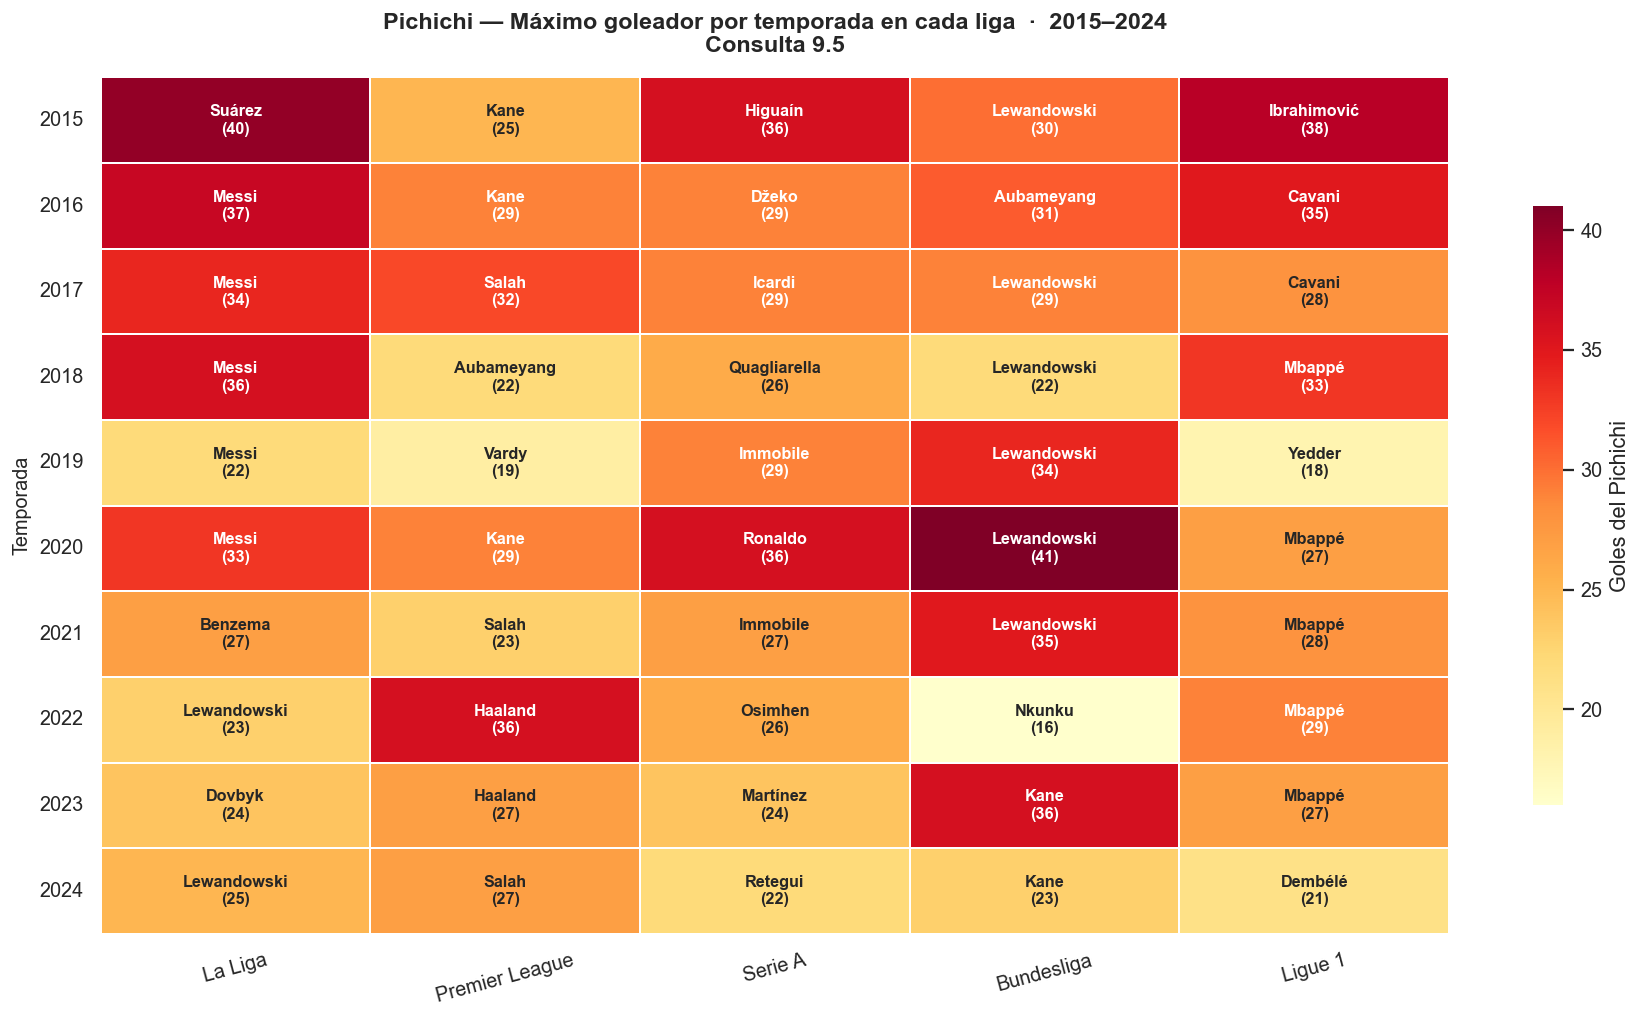

 temporada           liga                   jugador                                         club  goles  goles_por_partido
      2015     bundesliga        Robert Lewandowski                            FC Bayern München     30               0.94
      2016     bundesliga Pierre-Emerick Aubameyang                            Borussia Dortmund     31               0.97
      2017     bundesliga        Robert Lewandowski                            FC Bayern München     29               0.97
      2018     bundesliga        Robert Lewandowski                            FC Bayern München     22               0.67
      2019     bundesliga        Robert Lewandowski                            FC Bayern München     34               1.10
      2020     bundesliga        Robert Lewandowski                            FC Bayern München     41               1.41
      2021     bundesliga        Robert Lewandowski                            FC Bayern München     35               1.03
      2022     b

In [47]:
# ── Consulta 9.5 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
# Nota Python: RANK() puede devolver empates (rk=1 para dos jugadores con mismos goles).
# Se resuelve en Python con drop_duplicates, sin modificar la consulta.
# comp.name devuelve claves lowercase ('laliga', 'premier-league'…) → se usan
# directamente con LIGA_COLORS/LIGA_LABELS/LIGA_ORDER.
SQL_PICHICHI = """
SELECT
    liga, temporada, jugador, club, goles, partidos, goles_por_partido
FROM (
    SELECT
        comp.name                                   AS liga,
        d.season_start_year                         AS temporada,
        p.name                                      AS jugador,
        STRING_AGG(DISTINCT c.name, ', ')           AS club,
        SUM(fa.goals)                               AS goles,
        COUNT(DISTINCT fa.game_id)                  AS partidos,
        ROUND(SUM(fa.goals)::NUMERIC / NULLIF(COUNT(DISTINCT fa.game_id), 0), 2)
                                                    AS goles_por_partido,
        RANK() OVER (
            PARTITION BY comp.name, d.season_start_year
            ORDER BY SUM(fa.goals) DESC
        )                                           AS rk
    FROM dwh.fact_appearances fa
        INNER JOIN dwh.dim_players p         ON fa.player_id     = p.player_id
        INNER JOIN dwh.dim_clubs c           ON fa.club_id       = c.club_id
        INNER JOIN dwh.dim_date d            ON fa.date_id       = d.date_id
        INNER JOIN dwh.dim_competitions comp ON fa.competition_id = comp.competition_id
    WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND p.player_id != -1
      AND d.season_start_year BETWEEN 2015 AND 2024
    GROUP BY comp.name, d.season_start_year, p.name
    HAVING SUM(fa.goals) > 0
) goleadores
WHERE rk = 1
ORDER BY liga, temporada;
"""

df_pich = run_query(SQL_PICHICHI)
df_pich['goles']     = df_pich['goles'].astype(int)
df_pich['temporada'] = df_pich['temporada'].astype(int)
df_pich['goles_por_partido'] = pd.to_numeric(df_pich['goles_por_partido'], errors='coerce')

# RANK puede devolver empates → keep el primero por orden de nombre (ORDER BY SUM DESC, p.name)
df_pich = df_pich.drop_duplicates(subset=['liga', 'temporada'], keep='first')

# comp.name ya devuelve las claves lowercase — no hace falta ID_TO_LIGA
pivot_goles = df_pich.pivot(index='temporada', columns='liga', values='goles')
pivot_label = df_pich.pivot(index='temporada', columns='liga', values='jugador')

ordered_cols = [c for c in LIGA_ORDER if c in pivot_goles.columns]
pivot_goles  = pivot_goles[ordered_cols].rename(columns=LIGA_LABELS)
pivot_label  = pivot_label[ordered_cols].rename(columns=LIGA_LABELS)

def short_name(name):
    parts = str(name).split()
    return parts[-1] if len(parts) > 1 else name

annot_matrix = pivot_label.copy().astype(object)
for col in pivot_label.columns:
    for idx in pivot_label.index:
        j = pivot_label.at[idx, col]
        g = pivot_goles.at[idx, col]
        annot_matrix.at[idx, col] = (
            f"{short_name(str(j))}\n({int(g)})" if pd.notna(j) and pd.notna(g) else ''
        )

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_goles.astype(float),
    annot=annot_matrix,
    fmt='',
    cmap='YlOrRd',
    linewidths=1, linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Goles del Pichichi', 'shrink': 0.7},
    annot_kws={'size': 9, 'weight': 'bold'},
)
ax.set_title(
    'Pichichi — Máximo goleador por temporada en cada liga  ·  2015–2024\n'
    'Consulta 9.5',
    fontsize=13, fontweight='bold', pad=14,
)
ax.set_xlabel('')
ax.set_ylabel('Temporada', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_fig('viz_03_pichichi_heatmap.png')
plt.show()

print(df_pich[['temporada', 'liga', 'jugador', 'club', 'goles', 'goles_por_partido']]
      .sort_values(['liga', 'temporada']).to_string(index=False))


---
## 4. DICE + CTEs + FULL OUTER JOIN — Balance gastos / ingresos por club
**Consulta 9.6** · Tablas: `fact_transfers`, `dim_clubs`, `dim_competitions`

### ¿Qué hace la consulta?
Define dos CTEs independientes que acceden a `fact_transfers` desde perspectivas opuestas: **`gastos`** suma las compras de cada club (`to_club_id`) y **`ingresos`** suma las ventas (`from_club_id`). El `FULL OUTER JOIN` entre ambas garantiza incluir clubs que solo compran o solo venden. `COALESCE` gestiona los `NULL` que surgen del outer join. El **balance neto** es `(ingresos - gastos) / 1e6` en M€, y la columna `estado` clasifica cada club como `SUPERAVIT` o `DEFICIT`.

- **DICE:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` — solo Big Five
- **`FILTER (WHERE transfer_fee > 0)`:** excluye cesiones gratuitas y fichajes sin coste declarado
- **`FULL OUTER JOIN`:** esencial para no perder clubs con actividad exclusiva de compra o venta
- **`LIMIT 30`:** restringe a los 30 clubs con mayor desequilibrio (por balance neto ASC)

### ¿Cómo se visualiza?
En Python se seleccionan los **12 clubs con mayor déficit** y los **12 con mayor superávit** usando `nsmallest` y `nlargest`, que se concatenan y ordenan para formar el eje Y. Se construye un **gráfico de barras horizontales divergentes**: las barras que cruzan hacia la izquierda (balance negativo) se pintan en rojo y las que apuntan a la derecha (balance positivo) en verde. Una línea vertical en `x=0` actúa como eje central.

En el extremo izquierdo de cada barra se añade un **punto de color** (`ax.scatter`) usando `LIGA_COLORS` con la clave lowercase de `comp.name`, permitiendo identificar visualmente a qué liga pertenece cada club. El valor del balance (`+/-M€`) se anota en texto fuera de cada barra. La leyenda combina parches de estado (déficit/superávit) con los puntos de color de las 5 ligas.

**Operación OLAP:** `DICE` (Big Five) + `CTEs` + `FULL OUTER JOIN` + balance neto


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_04_balance_gastos_ingresos.png


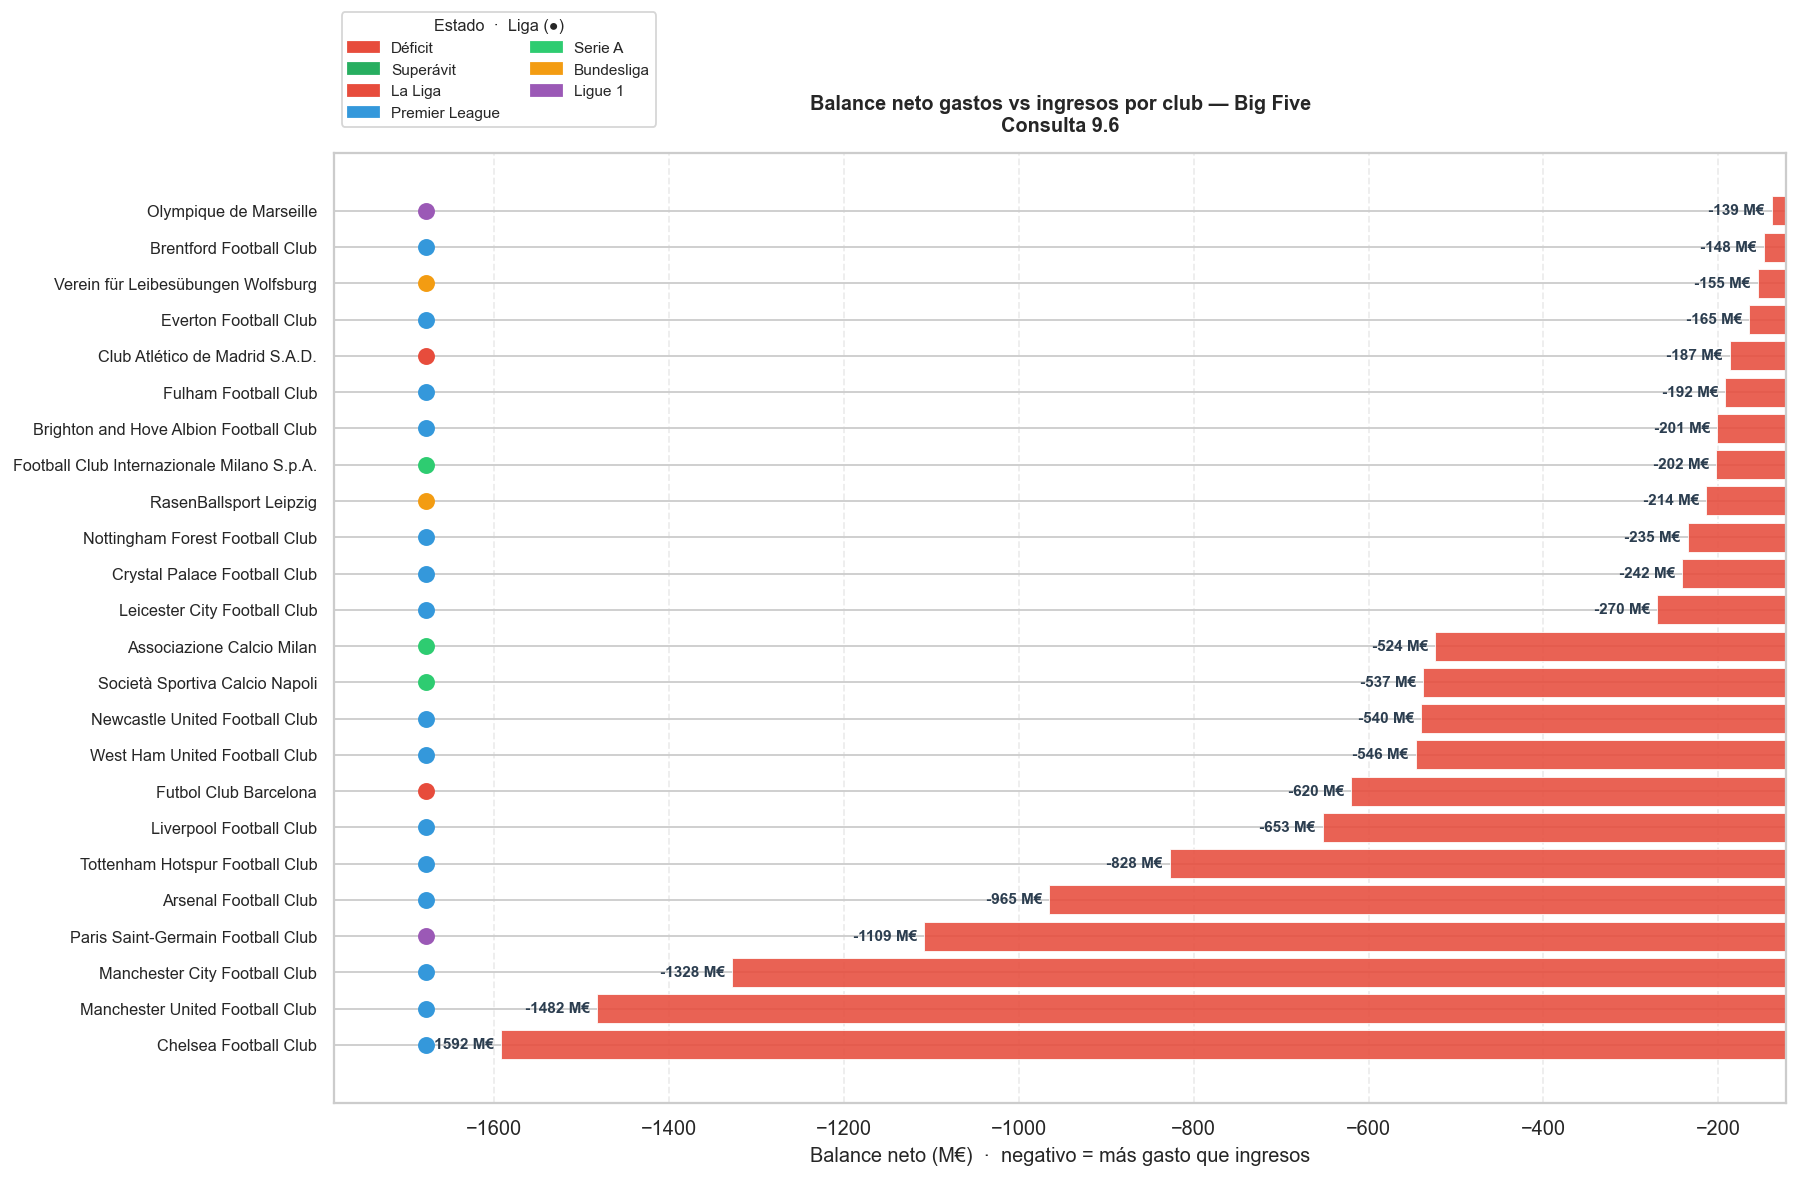

                                      club           liga  gastado_m  ingresado_m  balance_neto_m  estado
                     Chelsea Football Club premier-league     2521.8        930.0         -1591.8 DEFICIT
           Manchester United Football Club premier-league     1967.5        485.2         -1482.3 DEFICIT
             Manchester City Football Club premier-league     2092.1        764.4         -1327.8 DEFICIT
         Paris Saint-Germain Football Club        ligue-1     1587.8        479.2         -1108.7 DEFICIT
                     Arsenal Football Club premier-league     1365.8        400.6          -965.2 DEFICIT
           Tottenham Hotspur Football Club premier-league     1333.0        505.5          -827.5 DEFICIT
                   Liverpool Football Club premier-league     1130.5        477.9          -652.6 DEFICIT
                     Futbol Club Barcelona         laliga     1338.8        718.8          -620.0 DEFICIT
             West Ham United Football Club pre

In [77]:

# ── Consulta 9.6 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
SQL_BALANCE = """
WITH gastos AS (
    SELECT
        c.name AS club,
        comp.name AS liga,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0) AS total_gastado
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.to_club_id = c.club_id
        LEFT JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE c.club_id != -1
      AND comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY c.name, comp.name
),
ingresos AS (
    SELECT
        c.name AS club,
        comp.name AS liga,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0) AS total_ingresado
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.from_club_id = c.club_id
        LEFT JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE c.club_id != -1
      AND comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY c.name, comp.name
)
SELECT
    COALESCE(g.club, i.club)                        AS club,
    COALESCE(g.liga, i.liga)                        AS liga,
    ROUND(COALESCE(g.total_gastado, 0) / 1e6, 1)   AS gastado_M,
    ROUND(COALESCE(i.total_ingresado, 0) / 1e6, 1) AS ingresado_M,
    ROUND((COALESCE(i.total_ingresado, 0) - COALESCE(g.total_gastado, 0)) / 1e6, 1)
                                                    AS balance_neto_M,
    CASE
        WHEN COALESCE(i.total_ingresado, 0) > COALESCE(g.total_gastado, 0) THEN 'SUPERAVIT'
        ELSE 'DEFICIT'
    END                                             AS estado
FROM gastos g
    FULL OUTER JOIN ingresos i ON g.club = i.club
ORDER BY balance_neto_M ASC
LIMIT 30;
"""

df_bal = run_query(SQL_BALANCE)
for col in ['gastado_m', 'ingresado_m', 'balance_neto_m']:
    df_bal[col] = pd.to_numeric(df_bal[col], errors='coerce')

n = 12
df_plot = pd.concat([
    df_bal.nsmallest(n, 'balance_neto_m'),
    df_bal.nlargest(n,  'balance_neto_m'),
]).drop_duplicates('club').sort_values('balance_neto_m')

bar_colors = ['#e74c3c' if v < 0 else '#27ae60' for v in df_plot['balance_neto_m']]

fig, ax = plt.subplots(figsize=(14, 11))
# Espacio superior para la leyenda fuera del área de barras
fig.subplots_adjust(top=0.84, left=0.28)

bars = ax.barh(df_plot['club'], df_plot['balance_neto_m'],
               color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.88)
ax.axvline(0, color='#2c3e50', linewidth=1.2)

x_min_data = df_plot['balance_neto_m'].min()
x_max_data = df_plot['balance_neto_m'].max()
left_pad   = abs(x_min_data) * 0.12
ax.set_xlim(x_min_data - left_pad, x_max_data + abs(x_max_data) * 0.12)
dot_x = x_min_data - left_pad * 0.45

for bar, val, liga in zip(bars, df_plot['balance_neto_m'], df_plot['liga']):
    xpos = bar.get_width() + (8 if val >= 0 else -8)
    ha   = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height() / 2,
            f'{val:+.0f} M€', va='center', ha=ha,
            fontsize=8.5, fontweight='bold', color='#2c3e50')
    # Punto de liga en margen izquierdo (fuera de las barras)
    ax.scatter(dot_x, bar.get_y() + bar.get_height() / 2,
               color=LIGA_COLORS.get(liga, '#95a5a6'), s=70, zorder=5, clip_on=False)

ax.set_xlabel('Balance neto (M€)  ·  negativo = más gasto que ingresos', fontsize=11)
ax.set_title(
    'Balance neto gastos vs ingresos por club — Big Five\n'
    'Consulta 9.6',
    fontsize=11, fontweight='bold', pad=12,
)
ax.tick_params(axis='y', labelsize=9)

# Leyenda encima de los nombres de equipo (fuera del área de barras, esquina superior izquierda)
deficit_p   = mpatches.Patch(color='#e74c3c', label='Déficit')
superavit_p = mpatches.Patch(color='#27ae60', label='Superávit')
liga_handles = [mpatches.Patch(color=LIGA_COLORS[l], label=LIGA_LABELS[l]) for l in LIGA_ORDER]
ax.legend(
    handles=[deficit_p, superavit_p] + liga_handles,
    bbox_to_anchor=(0, 1.02), loc='lower left',
    ncol=2, fontsize=8.5, title='Estado  ·  Liga (●)', title_fontsize=9,
    frameon=True,
)

ax.grid(axis='x', linestyle='--', alpha=0.35)
plt.tight_layout(rect=[0, 0, 1, 0.84])
save_fig('viz_04_balance_gastos_ingresos.png')
plt.show()

print(df_plot[['club', 'liga', 'gastado_m', 'ingresado_m', 'balance_neto_m', 'estado']].to_string(index=False))


---
## 5. SLICE + CASE WHEN — Distribución de goles por franja de minuto
**Consulta 9.7** · Tablas: `fact_game_events`, `dim_competitions`

### ¿Qué hace la consulta?
Realiza un **SLICE** sobre `fact_game_events` filtrando únicamente los eventos de tipo `'Goals'` en las Big Five con `minute > 0`. Un bloque `CASE WHEN` clasifica cada gol en una de **7 franjas de 15 minutos**: 01-15, 16-30, 31-45, 46-60, 61-75, 76-90 y 90+ (tiempo añadido). El `GROUP BY` repite la expresión `CASE WHEN` completa (PostgreSQL no permite alias en `GROUP BY`). La función de ventana `SUM(COUNT(*)) OVER ()` sobre el `COUNT(*)` agrupado calcula el porcentaje de cada franja sobre el total global en una sola pasada, sin necesidad de subconsulta.

- **`OVER ()`:** ventana sin partición → el denominador es el total absoluto de todos los goles Big Five
- **`ORDER BY MIN(ge.minute)`:** ordena las franjas cronológicamente, no alfabéticamente
- **Nota:** si no existen eventos con `minute > 90` en el dataset, la franja `90+` no aparece en el resultado

### ¿Cómo se visualiza?
En Python se extrae el código de franja (ej. `01-15`) para construir etiquetas cortas en dos líneas. Se genera un **gráfico de barras verticales** con 7 posibles barras, coloreadas en **tres grupos cromáticos**: tonos verdes progresivamente oscuros para la primera parte (franjas 1–3), tonos azules para la segunda parte (franjas 4–6) y rojo para el tiempo añadido (franja 7). El número de goles y su porcentaje se anotan sobre cada barra en texto negrita.

Una **línea horizontal discontinua naranja** marca la media de goles por franja como referencia. Una **línea vertical punteada gris** separa la primera parte de la segunda (entre la 3ª y 4ª barra), acompañada de la etiqueta `DESCANSO`. La leyenda agrupa las tres categorías de color (1ª parte, 2ª parte, tiempo añadido).

**Operación OLAP:** `SLICE` (Big Five, type=Goals) + `WINDOW SUM OVER ()` para porcentaje en una pasada


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_05_goles_por_minuto.png


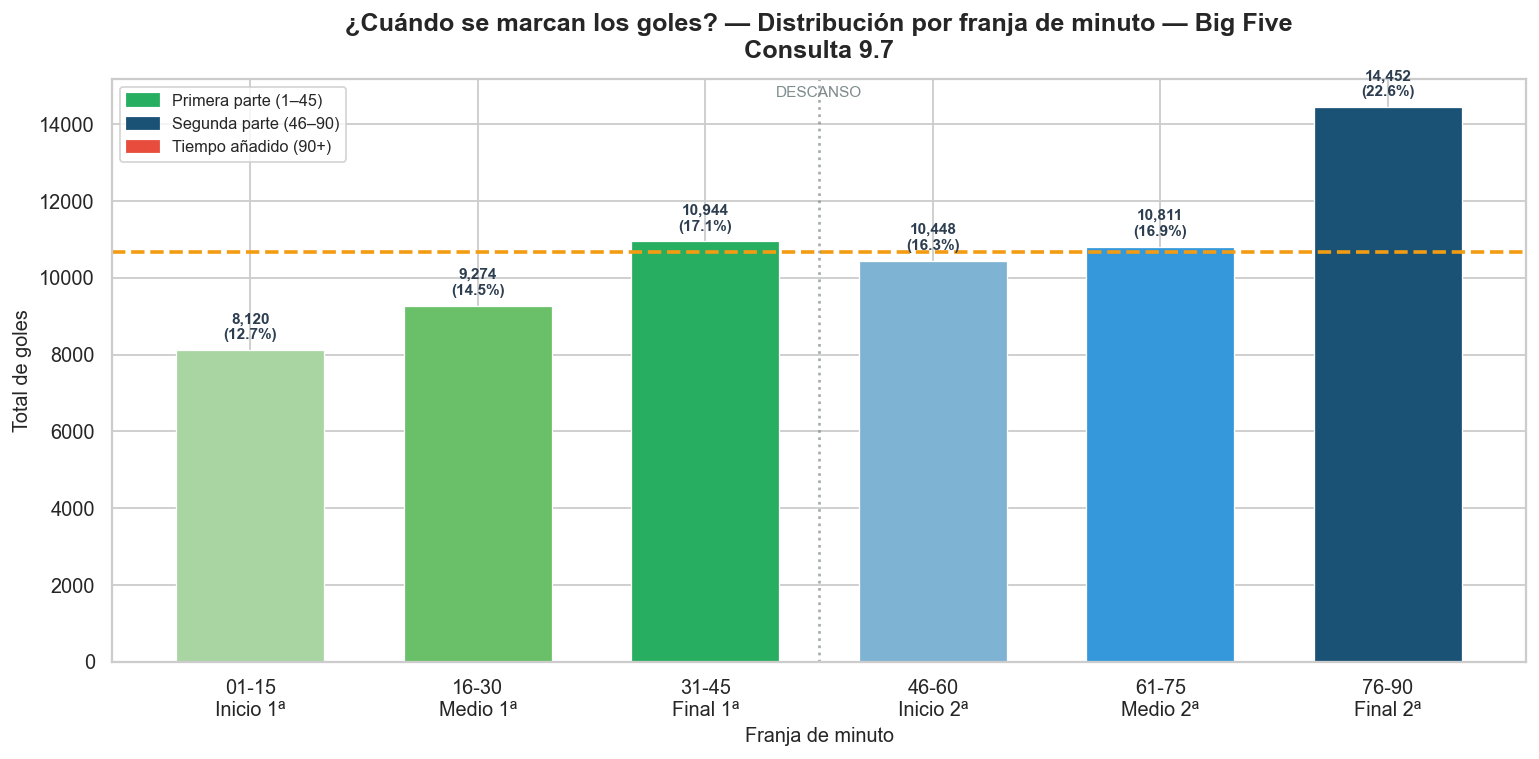

         franja_minutos  total_goles  porcentaje
01-15 (Inicio 1ª parte)         8120        12.7
 16-30 (Media 1ª parte)         9274        14.5
 31-45 (Final 1ª parte)        10944        17.1
46-60 (Inicio 2ª parte)        10448        16.3
 61-75 (Media 2ª parte)        10811        16.9
 76-90 (Final 2ª parte)        14452        22.6


In [48]:
# ── Consulta 9.7 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
SQL_MINUTOS = """
SELECT
    CASE
        WHEN ge.minute BETWEEN 1  AND 15  THEN '01-15 (Inicio 1ª parte)'
        WHEN ge.minute BETWEEN 16 AND 30  THEN '16-30 (Media 1ª parte)'
        WHEN ge.minute BETWEEN 31 AND 45  THEN '31-45 (Final 1ª parte)'
        WHEN ge.minute BETWEEN 46 AND 60  THEN '46-60 (Inicio 2ª parte)'
        WHEN ge.minute BETWEEN 61 AND 75  THEN '61-75 (Media 2ª parte)'
        WHEN ge.minute BETWEEN 76 AND 90  THEN '76-90 (Final 2ª parte)'
        WHEN ge.minute > 90               THEN '90+   (Tiempo añadido)'
        ELSE 'Desconocido'
    END                                             AS franja_minutos,
    COUNT(*)                                        AS total_goles,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS porcentaje
FROM dwh.fact_game_events ge
WHERE ge.type = 'Goals'
  AND ge.competition_id IN ('ES1','GB1','IT1','FR1','L1')
  AND ge.minute > 0
GROUP BY
    CASE
        WHEN ge.minute BETWEEN 1  AND 15  THEN '01-15 (Inicio 1ª parte)'
        WHEN ge.minute BETWEEN 16 AND 30  THEN '16-30 (Media 1ª parte)'
        WHEN ge.minute BETWEEN 31 AND 45  THEN '31-45 (Final 1ª parte)'
        WHEN ge.minute BETWEEN 46 AND 60  THEN '46-60 (Inicio 2ª parte)'
        WHEN ge.minute BETWEEN 61 AND 75  THEN '61-75 (Media 2ª parte)'
        WHEN ge.minute BETWEEN 76 AND 90  THEN '76-90 (Final 2ª parte)'
        WHEN ge.minute > 90               THEN '90+   (Tiempo añadido)'
        ELSE 'Desconocido'
    END
ORDER BY MIN(ge.minute);
"""

df_min = run_query(SQL_MINUTOS)
df_min['total_goles'] = df_min['total_goles'].astype(int)
df_min['porcentaje']  = pd.to_numeric(df_min['porcentaje'], errors='coerce')

# Acortar etiquetas para el eje X (el rango completo sigue en el tooltip al imprimir)
df_min['label'] = df_min['franja_minutos'].str.extract(r'^(\S+)').squeeze()
df_min['label'] = df_min['label'].str.replace(r'\s+', '\n', regex=True)
label_desc = {
    '01-15': '01-15\nInicio 1ª',
    '16-30': '16-30\nMedio 1ª',
    '31-45': '31-45\nFinal 1ª',
    '46-60': '46-60\nInicio 2ª',
    '61-75': '61-75\nMedio 2ª',
    '76-90': '76-90\nFinal 2ª',
    '90+':   '90+\nAñadido',
}
df_min['label'] = df_min['label'].map(label_desc).fillna(df_min['label'])

colors_franja = [
    '#a8d5a2', '#6abf69', '#27ae60',
    '#7fb3d3', '#3498db', '#1a5276',
    '#e74c3c',
]
bar_colors = colors_franja[:len(df_min)]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(df_min['label'], df_min['total_goles'],
              color=bar_colors, edgecolor='white', linewidth=0.7, width=0.65)

for bar, val, pct in zip(bars, df_min['total_goles'], df_min['porcentaje']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#2c3e50')

media = df_min['total_goles'].mean()
ax.axhline(media, color='#f39c12', linewidth=2, linestyle='--',
           label=f'Media por franja ({media:,.0f})')

ax.set_ylabel('Total de goles', fontsize=11)
ax.set_xlabel('Franja de minuto', fontsize=11)
ax.set_title(
    '¿Cuándo se marcan los goles? — Distribución por franja de minuto — Big Five\n'
    'Consulta 9.7',
    fontsize=14, fontweight='bold', pad=12,
)

legend_handles = [
    mpatches.Patch(color='#27ae60', label='Primera parte (1–45)'),
    mpatches.Patch(color='#1a5276', label='Segunda parte (46–90)'),
    mpatches.Patch(color='#e74c3c', label='Tiempo añadido (90+)'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='upper left')
ax.axvline(2.5, color='#7f8c8d', linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(2.5, ax.get_ylim()[1] * 0.97, 'DESCANSO', ha='center', fontsize=8.5, color='#7f8c8d')

plt.tight_layout()
save_fig('viz_05_goles_por_minuto.png')
plt.show()

print(df_min[['franja_minutos', 'total_goles', 'porcentaje']].to_string(index=False))


---
## 6. ROLL-UP + LAG — Inflación del mercado de fichajes (2012–2025)
**Consulta 9.9** · Tablas: `fact_transfers`, `dim_date`

### ¿Qué hace la consulta?
Hace un **Roll-Up temporal** al nivel de año (`d.year`) sobre `fact_transfers`. Una CTE previa `base` encapsula cuatro agregados aplicados únicamente a transferencias con precio conocido (`FILTER (WHERE transfer_fee > 0)`): precio medio con `AVG`, mediana exacta con `PERCENTILE_CONT(0.5) WITHIN GROUP`, máximo con `MAX` y total de mercado con `SUM`. Sobre la CTE, la consulta exterior añade `LAG(precio_medio_M) OVER (ORDER BY anio)` para acceder al valor del año anterior y calcular la variación interanual porcentual en un segundo pase sin necesidad de self-join.

- **`PERCENTILE_CONT(0.5)`:** función de ordenación estadística, calcula la mediana exacta (no el percentil discreto); el `FILTER` la aplica solo sobre los precios reales
- **`LAG(...) OVER (ORDER BY anio)`:** el primer año devuelve `NULL` como denominador → `NULLIF(..., 0)` lo convierte en `NULL` en el resultado, evitando errores
- **Resultado:** 14 filas (2012–2025) con métricas por año de transferencia

### ¿Cómo se visualiza?
Se construye un **gráfico de doble eje Y**. En el eje izquierdo se representan **barras azules** con el precio medio anual en M€, destacando en rojo la barra del año máximo, y una **línea discontinua naranja** con marcadores de la mediana. En el eje derecho se superpone una **línea roja con marcadores cuadrados** que muestra la variación interanual porcentual.

Se añaden dos **anotaciones con flechas**: una señala el crash del mercado en 2020 asociado al COVID-19 (caída del ~15%), y otra identifica el año con precio medio máximo. Los datos de ambos ejes se combinan en una única leyenda mediante `get_legend_handles_labels`. Las columnas recibidas en minúsculas desde PostgreSQL (`precio_medio_m`, `mediana_m`, `total_mercado_m`, `variacion_pct`) se usan directamente en pandas.

**Operación OLAP:** `ROLL-UP` temporal (día → año) + `WINDOW LAG` para variación interanual


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_06_inflacion_mercado.png


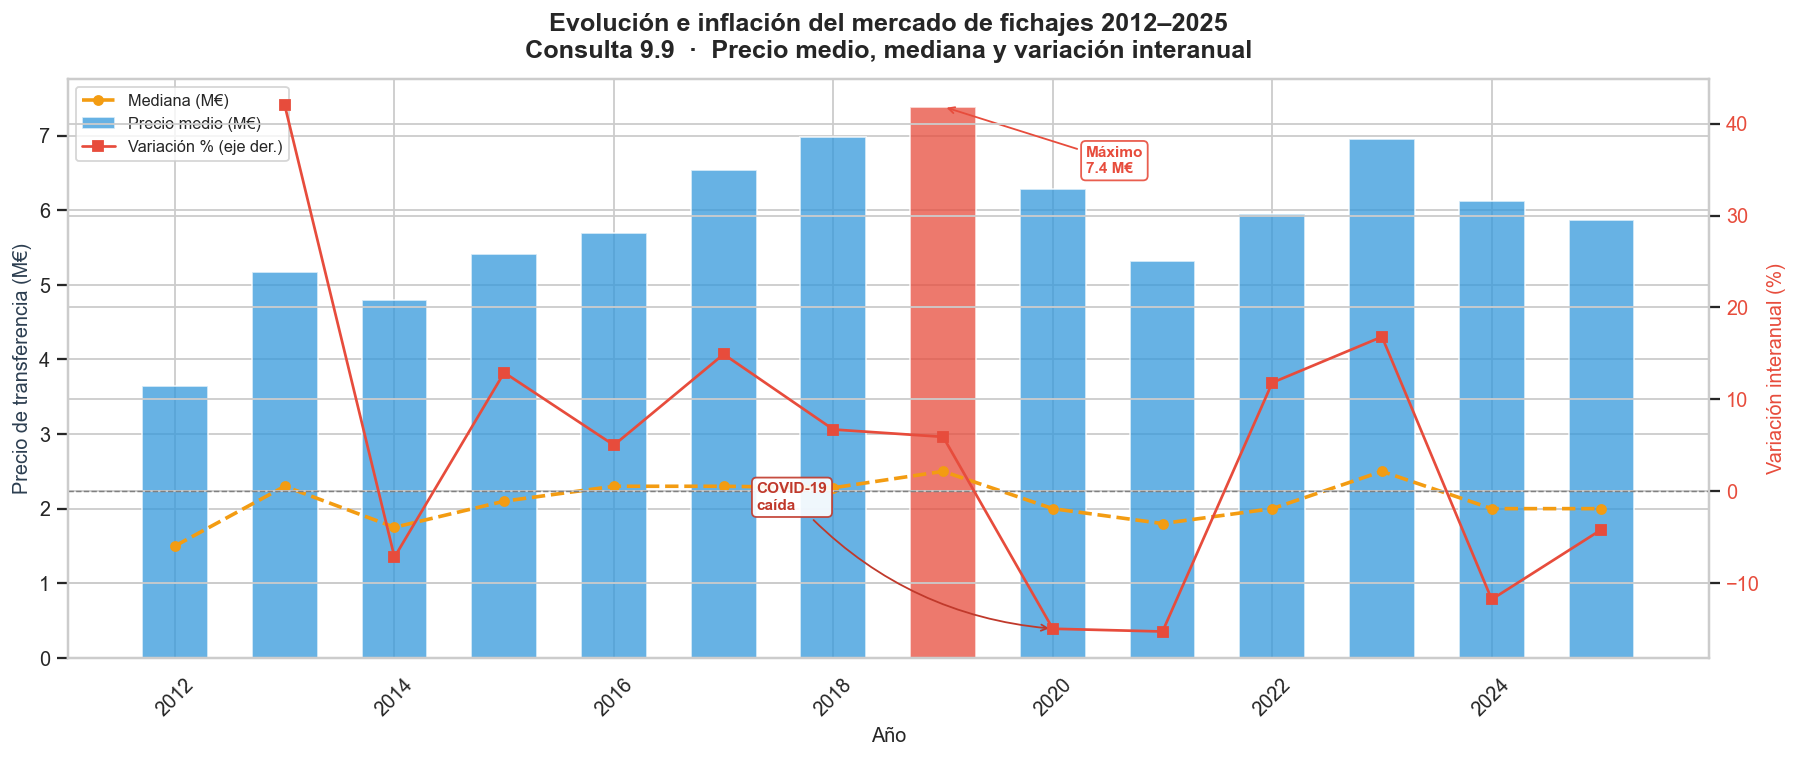

 anio  num_fichajes_con_precio  precio_medio_m  mediana_m  total_mercado_m  variacion_pct
 2012                      159            3.64       1.50            579.4            NaN
 2013                      260            5.17       2.30           1343.6           42.0
 2014                      284            4.80       1.75           1363.1           -7.2
 2015                      401            5.42       2.10           2172.6           12.9
 2016                      476            5.69       2.30           2708.1            5.0
 2017                      625            6.54       2.30           4087.9           14.9
 2018                      678            6.98       2.28           4731.5            6.7
 2019                      871            7.39       2.50           6440.0            5.9
 2020                      738            6.28       2.00           4638.2          -15.0
 2021                      757            5.32       1.80           4025.5          -15.3
 2022     

In [49]:
# ── Consulta 9.9 — SQL ORIGINAL de consultas_olap.sql ────────────────────────
# Nota Python: PostgreSQL normaliza alias sin comillas dobles a minúsculas.
#   precio_medio_M → precio_medio_m  |  mediana_M → mediana_m
#   maximo_M → maximo_m              |  total_mercado_M → total_mercado_m
SQL_INFLACION = """
WITH base AS (
    SELECT
        d.year                                      AS anio,
        COUNT(*) FILTER (WHERE t.transfer_fee > 0)  AS num_fichajes_con_precio,
        ROUND((AVG(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2)
                                                    AS precio_medio_M,
        ROUND((PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY t.transfer_fee)
              FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2)
                                                    AS mediana_M,
        ROUND(MAX(t.transfer_fee)::NUMERIC / 1e6, 1) AS maximo_M,
        ROUND((SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 1)
                                                    AS total_mercado_M
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_date d ON t.transfer_date_id = d.date_id
    WHERE d.year BETWEEN 2012 AND 2025
    GROUP BY d.year
)
SELECT
    anio,
    num_fichajes_con_precio,
    precio_medio_M,
    mediana_M,
    maximo_M,
    total_mercado_M,
    ROUND(100.0 * (precio_medio_M - LAG(precio_medio_M) OVER (ORDER BY anio))
        / NULLIF(LAG(precio_medio_M) OVER (ORDER BY anio), 0), 1) AS variacion_pct
FROM base
ORDER BY anio;
"""

df_inf = run_query(SQL_INFLACION)
# Columnas en minúsculas tal como llegan de PostgreSQL
for col in ['precio_medio_m', 'mediana_m', 'maximo_m', 'total_mercado_m', 'variacion_pct']:
    df_inf[col] = pd.to_numeric(df_inf[col], errors='coerce')

fig, ax1 = plt.subplots(figsize=(14, 6))

bar_colors = ['#e74c3c' if v == df_inf['precio_medio_m'].max() else '#3498db'
              for v in df_inf['precio_medio_m']]
bars = ax1.bar(df_inf['anio'], df_inf['precio_medio_m'],
               color=bar_colors, alpha=0.75, label='Precio medio (M€)', width=0.6)

ax1.plot(df_inf['anio'], df_inf['mediana_m'], 'o--', color='#f39c12',
         linewidth=2, markersize=5, label='Mediana (M€)', zorder=5)

ax1.set_ylabel('Precio de transferencia (M€)', fontsize=11, color='#2c3e50')
ax1.set_xlabel('Año', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
df_var = df_inf.dropna(subset=['variacion_pct'])
ax2.plot(df_var['anio'], df_var['variacion_pct'], 's-', color='#e74c3c',
         linewidth=1.5, markersize=6, label='Variación % (eje der.)', zorder=4)
ax2.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax2.set_ylabel('Variación interanual (%)', fontsize=11, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Anotación COVID-19 con caja blanca para no solapar año ni línea
covid_y = df_var.loc[df_var['anio'] == 2020, 'variacion_pct']
if not covid_y.empty:
    ax2.annotate('COVID-19\ncaída', xy=(2020, float(covid_y.iloc[0])),
                 xytext=(2017.3, float(covid_y.iloc[0]) + 13),
                 arrowprops=dict(arrowstyle='->', color='#c0392b',
                                 connectionstyle='arc3,rad=0.2'),
                 fontsize=8.5, color='#c0392b', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                           edgecolor='#c0392b', alpha=0.9))

# Anotación máximo con caja blanca para no solapar barra ni título
max_year = int(df_inf.loc[df_inf['precio_medio_m'].idxmax(), 'anio'])
max_val  = float(df_inf['precio_medio_m'].max())
ax1.annotate(f'Máximo\n{max_val:.1f} M€', xy=(max_year, max_val),
             xytext=(max_year + 1.3, max_val * 0.88),
             arrowprops=dict(arrowstyle='->', color='#e74c3c'),
             fontsize=8.5, color='#e74c3c', fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#e74c3c', alpha=0.9))

ax1.set_title(
    'Evolución e inflación del mercado de fichajes 2012–2025\n'
    'Consulta 9.9  ·  Precio medio, mediana y variación interanual',
    fontsize=14, fontweight='bold', pad=12,
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
save_fig('viz_06_inflacion_mercado.png')
plt.show()

print(df_inf[['anio', 'num_fichajes_con_precio', 'precio_medio_m',
              'mediana_m', 'total_mercado_m', 'variacion_pct']].to_string(index=False))


---
## 7. DICE + 3 CTEs — Radar Chart KPI Big Five
**Consulta 9.10** · Tablas: `fact_games`, `fact_transfers`, `fact_appearances`, `dim_clubs`, `dim_competitions`

### ¿Qué hace la consulta?
Construye tres CTEs independientes que calculan un KPI diferente por liga desde tres tablas de hechos distintas: **`goles_liga`** obtiene goles por partido y asistencia media desde `fact_games` (con `FILTER (WHERE attendance > 0)` para excluir partidos sin dato de aforo); **`fichajes_liga`** calcula el precio medio de transferencias en M€ desde `fact_transfers` + `dim_clubs` (con `FILTER (WHERE transfer_fee > 0)` para excluir cesiones); **`tarjetas_liga`** obtiene el porcentaje de tarjetas amarillas por aparición desde `fact_appearances`. La consulta principal une las tres CTEs mediante `INNER JOIN` y dos `LEFT JOIN`, generando una fila por liga con los 4 KPIs consolidados.

- **DICE:** `competition_id IN ('ES1','GB1','IT1','FR1','L1')` en las tres CTEs
- **Columnas adicionales:** `num_fichajes`, `gasto_total_B` y otras métricas se devuelven pero no se usan en el radar; Python solo lee las columnas que necesita
- **`fichaje_medio_m`** llega en minúsculas desde PostgreSQL (alias `fichaje_medio_M` normalizado a lowercase)

### ¿Cómo se visualiza?
En Python se construye un **radar chart** (gráfico polar) con `matplotlib` usando 4 ejes angulares equidistantes. Cada KPI se **normaliza al rango [0, 1]** con `(valor - min) / (max - min)` para que todas las dimensiones sean comparables. El KPI de tarjetas amarillas se **invierte** (`1 - normed`) porque un menor porcentaje es mejor. Los ángulos se cierran duplicando el primer valor al final.

Por cada liga se traza un **polígono con marcadores circulares** (`ax.plot`) coloreado con `LIGA_COLORS` y rellenado con transparencia del 10% (`ax.fill`). Las etiquetas de los ejes se posicionan automáticamente. La leyenda se ancla fuera del área del gráfico (`bbox_to_anchor`) para no solapar el radar. El eje polar tiene las marcas de radiales en 25%, 50%, 75% y 100%.

**Operación OLAP:** `DICE` (5 ligas, todos los años) + unión de 3 fuentes de hechos vía CTEs


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_07_radar_big5.png


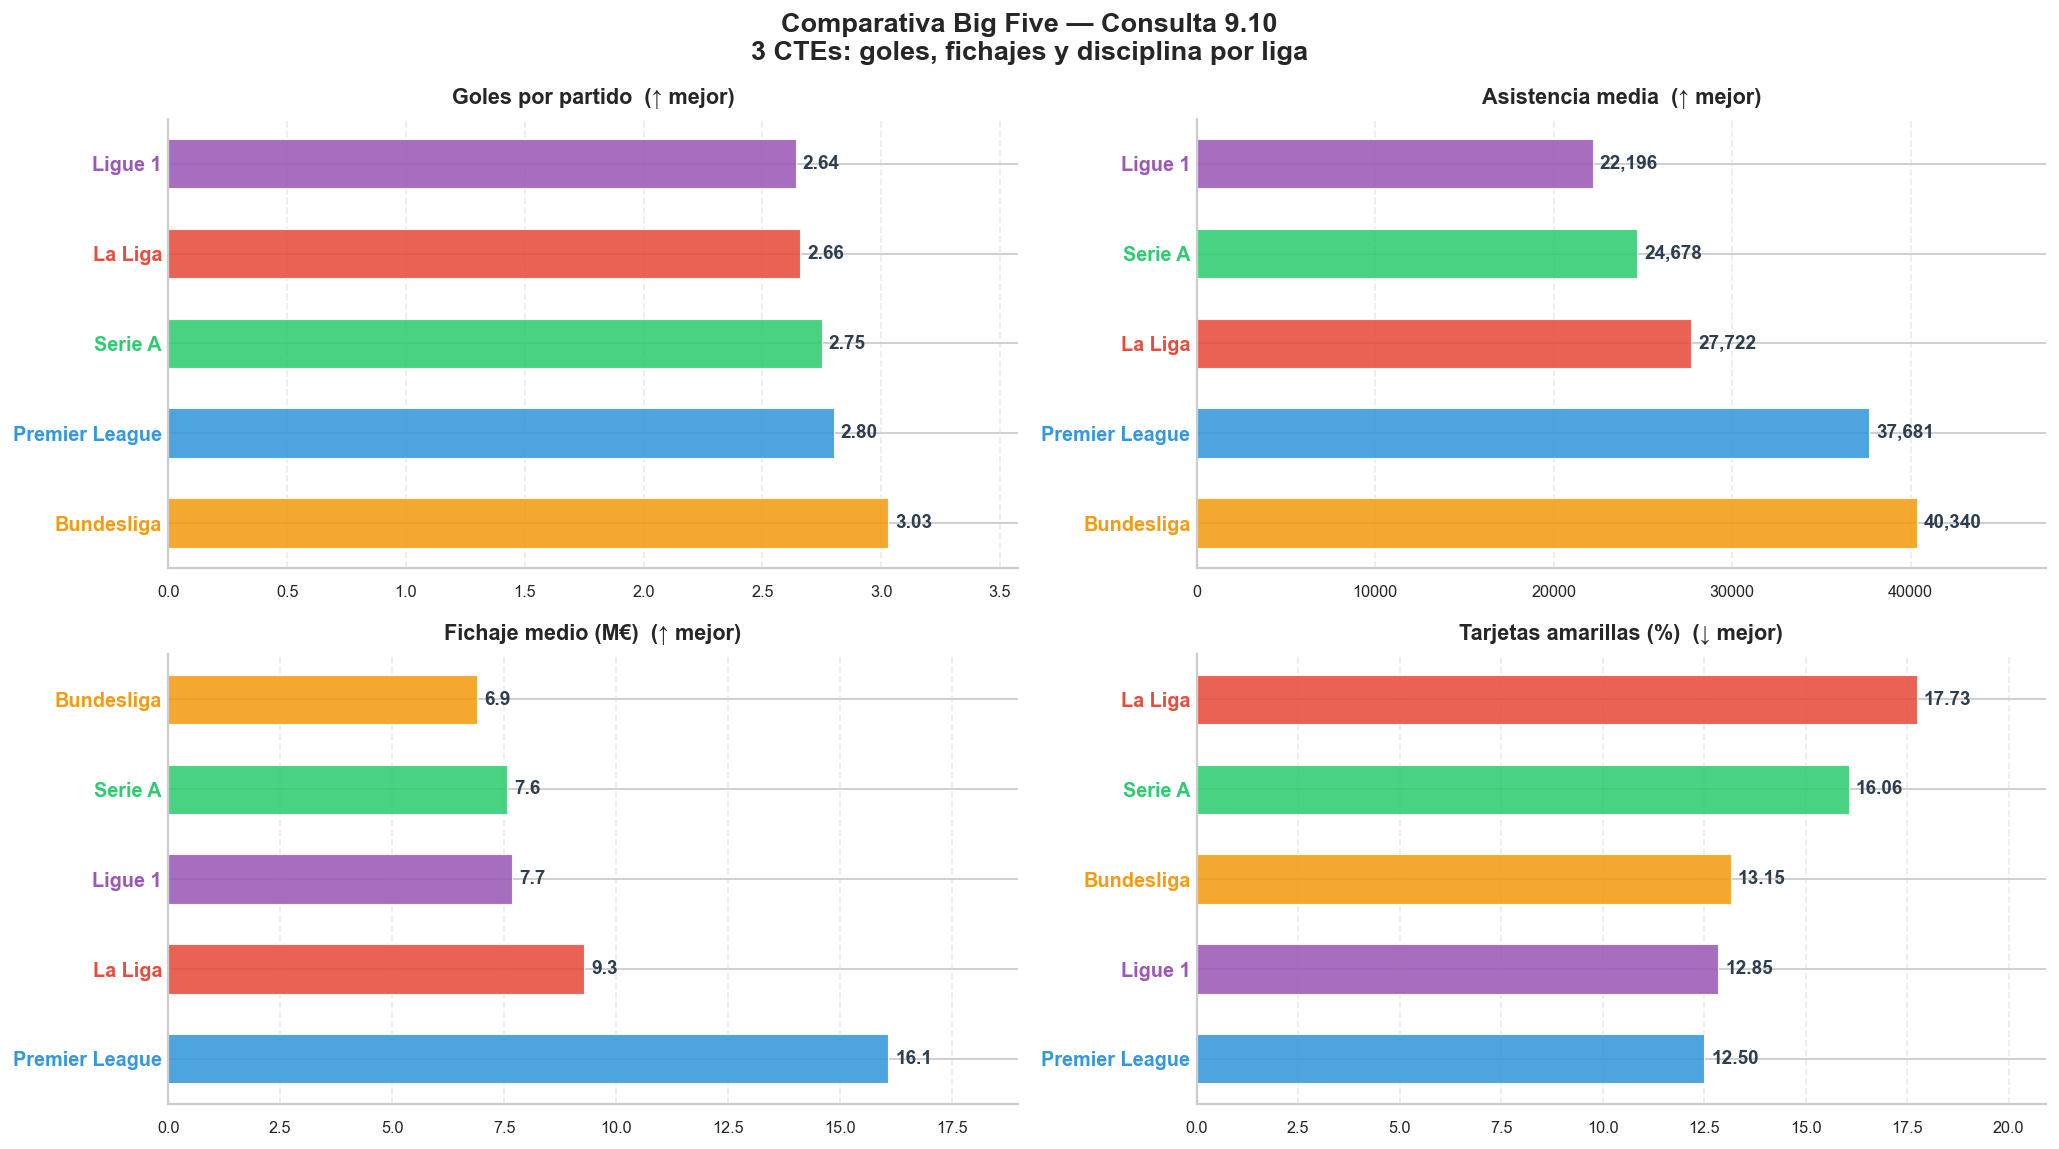

    liga_label  goles  goles_por_partido  asistencia_media  fichaje_medio_m  amarillas  pct_amarilla_por_aparicion
Premier League  13639               2.80           37681.0            16.08      16994                       12.50
       Serie A  13377               2.75           24678.0             7.56      22597                       16.06
       La Liga  12903               2.66           27722.0             9.28      24672                       17.73
       Ligue 1  12257               2.64           22196.0             7.67      16972                       12.85
    Bundesliga  11881               3.03           40340.0             6.90      14890                       13.15


In [61]:

# ── Consulta 9.10 — SQL ORIGINAL de consultas_olap.sql ───────────────────────
SQL_BIG5 = """
WITH goles_liga AS (
    SELECT
        fg.competition_id,
        COUNT(*)                                    AS partidos,
        SUM(fg.total_goals)                         AS goles,
        ROUND(AVG(fg.total_goals)::NUMERIC, 2)       AS goles_por_partido,
        ROUND((AVG(fg.attendance) FILTER (WHERE fg.attendance > 0))::NUMERIC, 0) AS asistencia_media
    FROM dwh.fact_games fg
    WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY fg.competition_id
),
fichajes_liga AS (
    SELECT
        comp.competition_id,
        COUNT(*) FILTER (WHERE t.transfer_fee > 0)  AS num_fichajes,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0) AS gasto_total,
        ROUND((AVG(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0))::NUMERIC / 1e6, 2) AS fichaje_medio_M
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.to_club_id = c.club_id
        LEFT JOIN dwh.dim_competitions comp ON c.domestic_competition_id = comp.competition_id
    WHERE comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND c.club_id != -1
    GROUP BY comp.competition_id
),
tarjetas_liga AS (
    SELECT
        fa.competition_id,
        SUM(fa.yellow_cards)                        AS amarillas,
        SUM(fa.red_cards)                           AS rojas,
        ROUND(100.0 * SUM(fa.yellow_cards) / COUNT(*), 2) AS pct_amarilla_por_aparicion
    FROM dwh.fact_appearances fa
    WHERE fa.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY fa.competition_id
)
SELECT
    comp.name                                       AS liga,
    g.partidos,
    g.goles,
    g.goles_por_partido,
    g.asistencia_media,
    f.num_fichajes,
    ROUND(f.gasto_total::NUMERIC / 1e9, 2)          AS gasto_total_B,
    f.fichaje_medio_M,
    t.amarillas,
    t.rojas,
    t.pct_amarilla_por_aparicion
FROM goles_liga g
    INNER JOIN dwh.dim_competitions comp ON g.competition_id = comp.competition_id
    LEFT JOIN fichajes_liga f ON g.competition_id = f.competition_id
    LEFT JOIN tarjetas_liga t ON g.competition_id = t.competition_id
ORDER BY g.goles DESC;
"""

df_big5 = run_query(SQL_BIG5)
for col in ['goles_por_partido', 'asistencia_media', 'fichaje_medio_m',
            'pct_amarilla_por_aparicion', 'goles', 'partidos',
            'amarillas', 'rojas', 'num_fichajes', 'gasto_total_b']:
    df_big5[col] = pd.to_numeric(df_big5[col], errors='coerce')

df_big5['liga_label'] = df_big5['liga'].map(LIGA_LABELS).fillna(df_big5['liga'])

# ── 4 subgráficos horizontales, uno por KPI ──────────────────────────────────
kpis = [
    ('goles_por_partido',         'Goles por partido',      '{:.2f}',  False),  # mayor = mejor
    ('asistencia_media',          'Asistencia media',        '{:,.0f}', False),
    ('fichaje_medio_m',           'Fichaje medio (M€)',      '{:.1f}',  False),
    ('pct_amarilla_por_aparicion','Tarjetas amarillas (%)',  '{:.2f}',  True),   # menor = mejor
]

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle(
    'Comparativa Big Five — Consulta 9.10\n'
    '3 CTEs: goles, fichajes y disciplina por liga',
    fontsize=15, fontweight='bold',
)

for ax, (col, titulo, fmt, invertir) in zip(axes, kpis):
    # Ordenar: mejor liga arriba (ascendente para barh → si invertir, menos es mejor)
    ascending = True if invertir else False
    df_sorted = df_big5.sort_values(col, ascending=ascending).reset_index(drop=True)

    colores_bar = [LIGA_COLORS.get(l, '#95a5a6') for l in df_sorted['liga']]
    vals_plot   = df_sorted[col].values
    max_val_kpi = vals_plot.max()

    bars = ax.barh(df_sorted['liga_label'], vals_plot,
                   color=colores_bar, edgecolor='white', linewidth=0.6,
                   alpha=0.88, height=0.55)

    # Valor al final de cada barra
    for bar, val in zip(bars, vals_plot):
        ax.text(bar.get_width() + max_val_kpi * 0.01,
                bar.get_y() + bar.get_height() / 2,
                fmt.format(val),
                va='center', ha='left', fontsize=10.5, fontweight='bold', color='#2c3e50')

    # Colorear etiquetas Y con el color de cada liga
    for tick, liga_key in zip(ax.get_yticklabels(), df_sorted['liga']):
        tick.set_color(LIGA_COLORS.get(liga_key, '#2c3e50'))
        tick.set_fontsize(11)
        tick.set_fontweight('bold')

    nota = '  (↓ mejor)' if invertir else '  (↑ mejor)'
    ax.set_title(titulo + nota, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlim(0, max_val_kpi * 1.18)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', which='both', length=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
save_fig('viz_07_radar_big5.png')
plt.show()

print(df_big5[['liga_label', 'goles', 'goles_por_partido', 'asistencia_media',
               'fichaje_medio_m', 'amarillas', 'pct_amarilla_por_aparicion']].to_string(index=False))


---
## 8. DICE + CTEs + NTILE — Inversión en fichajes vs % de victorias (2018–2024)
**Consulta 12.2** · Tablas: `fact_transfers`, `fact_games`, `dim_clubs`, `dim_competitions`, `dim_date`

### ¿Qué hace la consulta?
Define dos CTEs: **`gasto_por_club`** suma el gasto total en compras de cada club vinculando `fact_transfers` con `dim_date` para filtrar el período 2018–2024 (`transfer_season BETWEEN 2018 AND 2024`). **`resultados_por_club`** usa `UNION ALL` para tratar cada partido dos veces: una como equipo local y otra como visitante, contando victorias y partidos desde ambas perspectivas en `fact_games`. La consulta final hace JOIN entre ambas CTEs, aplica `NTILE(4) OVER (ORDER BY gasto_total DESC)` para clasificar los clubs en cuartiles de gasto y calcula el porcentaje de victorias. Se filtra por `partidos_totales >= 50` para garantizar significación estadística.

- **`UNION ALL` necesario:** `fact_games` tiene una fila por partido, no por equipo; sin `UNION ALL` no se contabilizarían las victorias visitantes
- **`NTILE(4)`:** cuartil 1 = clubs con mayor gasto, cuartil 4 = menor gasto; el cuartil determina el **tamaño visual** del punto
- **`LIMIT 30`:** los 30 clubs con mayor gasto total en el período
- **`gasto_m`** recibido en minúsculas desde PostgreSQL

### ¿Cómo se visualiza?
Se genera un **scatter plot** con `matplotlib` donde el eje X representa el gasto total acumulado en M€ y el eje Y el porcentaje de victorias. El **color de cada punto** se toma de `LIGA_COLORS` usando la clave lowercase de `comp.name`. El **tamaño del punto** escala inversamente al cuartil de gasto usando un diccionario `size_map` (cuartil 1 = punto más grande), distinguiendo así el nivel de inversión de cada club visualmente.

Se añade una **línea de tendencia lineal discontinua** calculada con `numpy.polyfit` de grado 1 sobre todos los clubs, mostrando si existe correlación positiva entre gasto y victorias. Un subconjunto de clubs destacados (outliers por posición respecto a la tendencia) reciben una **etiqueta de texto** con su nombre. La leyenda combina los colores de liga.

**Operación OLAP:** `DICE` (Big Five, 2018–2024) + `WINDOW NTILE(4)` + `UNION ALL` de resultados


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_08_gasto_vs_victorias.png


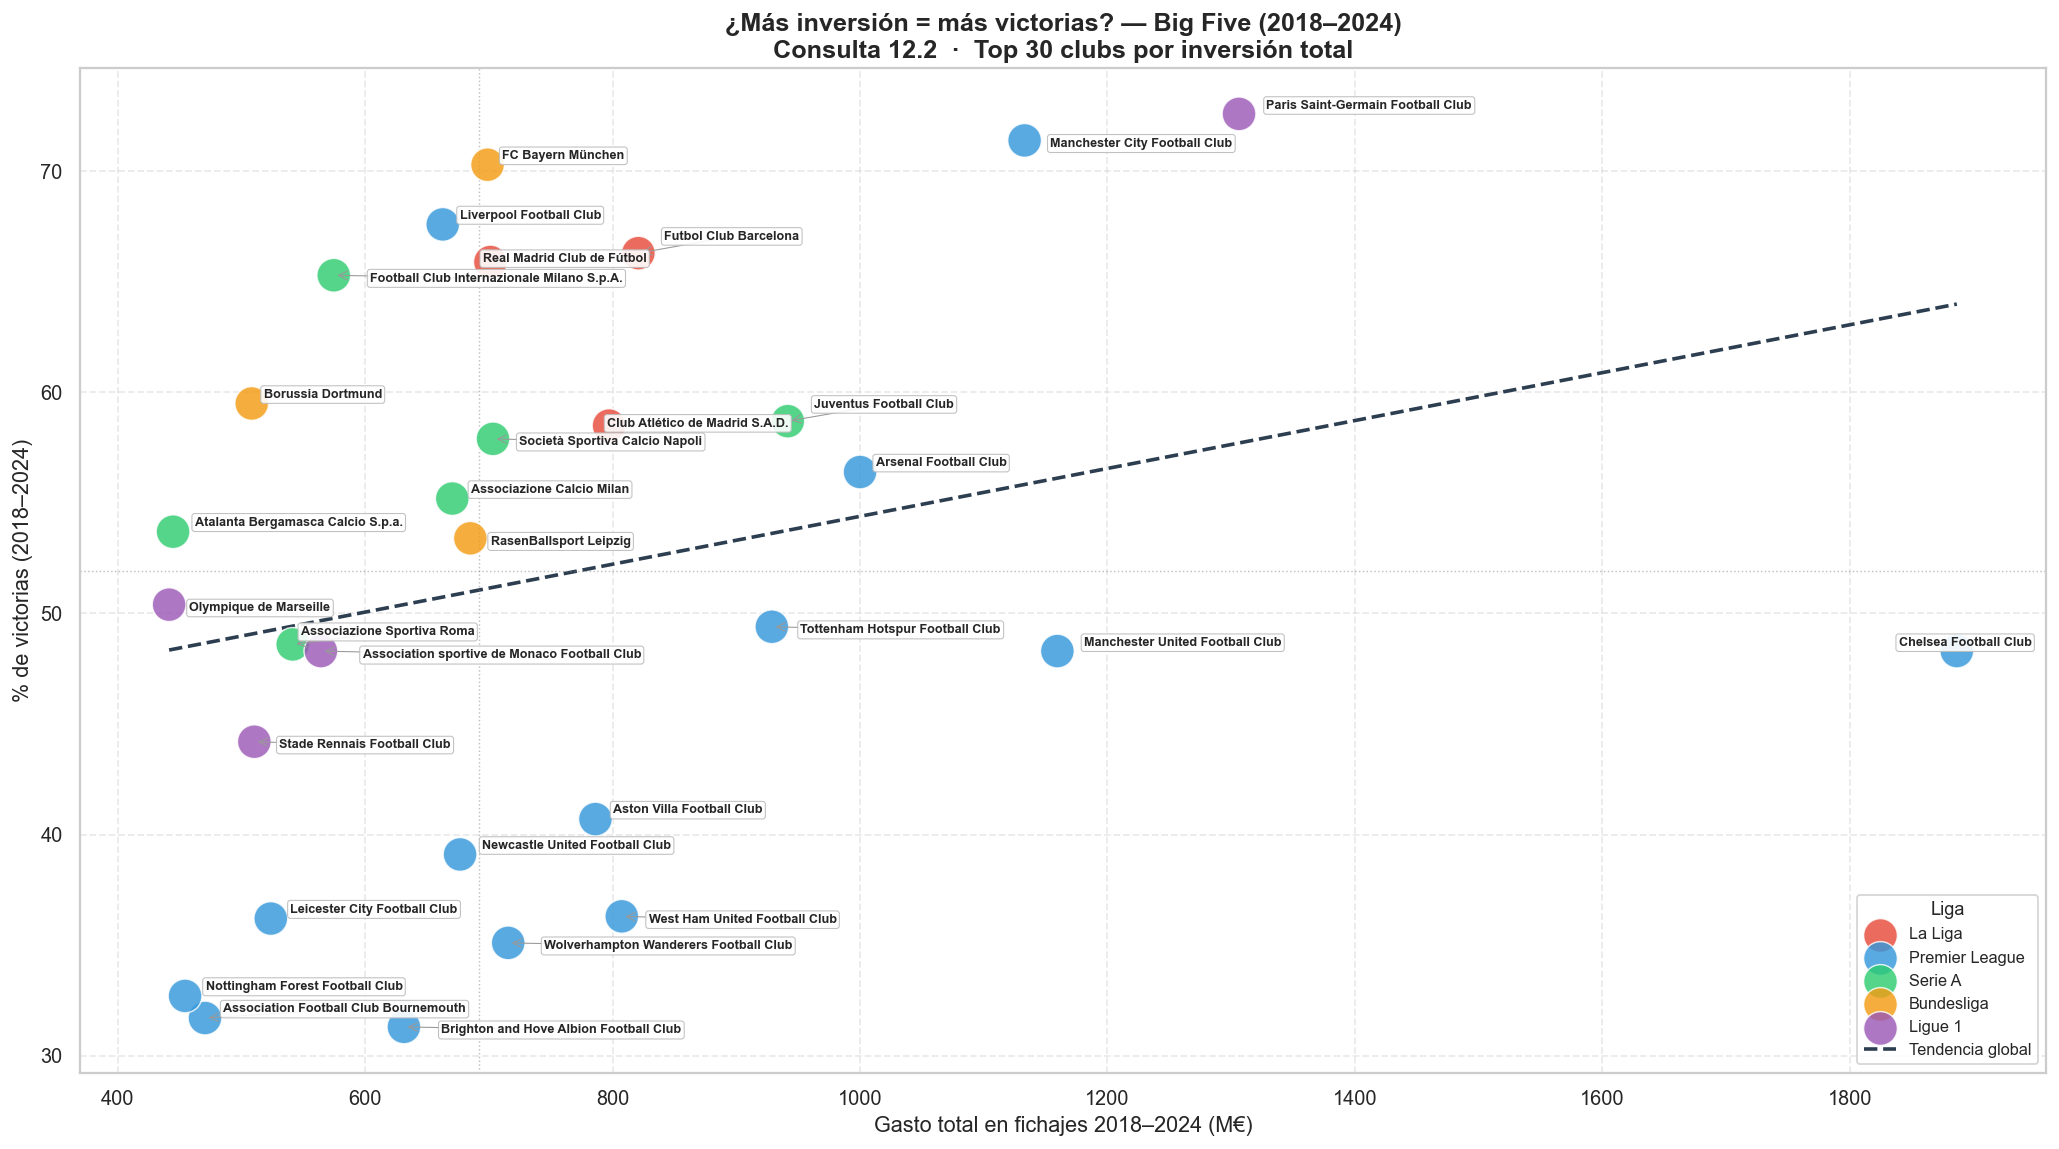

                                        club           liga  gasto_m  victorias  partidos_totales  pct_victorias  dif_goles  cuartil_gasto
                       Chelsea Football Club premier-league   1886.6      125.0             259.0           48.3      126.0              1
           Paris Saint-Germain Football Club        ligue-1   1306.4      175.0             241.0           72.6      384.0              1
             Manchester United Football Club premier-league   1159.6      125.0             259.0           48.3       80.0              1
               Manchester City Football Club premier-league   1133.1      185.0             259.0           71.4      403.0              1
                       Arsenal Football Club premier-league   1000.1      146.0             259.0           56.4      196.0              1
                      Juventus Football Club        serie-a    941.7      152.0             259.0           58.7      196.0              1
             Tottenham Hots

In [55]:

# ── Consulta 12.2 — SQL ORIGINAL de consultas_olap.sql ───────────────────────
# Nota Python: gasto_M → gasto_m  (PostgreSQL normaliza a minúsculas)
SQL_GASTO_VIC = """
WITH gasto_por_club AS (
    SELECT
        c.club_id,
        c.name                                                      AS club,
        comp.name                                                   AS liga,
        SUM(t.transfer_fee) FILTER (WHERE t.transfer_fee > 0)       AS gasto_total,
        COUNT(*) FILTER (WHERE t.transfer_fee > 0)                  AS num_fichajes_con_precio
    FROM dwh.fact_transfers t
        INNER JOIN dwh.dim_clubs c ON t.to_club_id = c.club_id
        LEFT  JOIN dwh.dim_competitions comp
            ON c.domestic_competition_id = comp.competition_id
    WHERE t.transfer_season BETWEEN 2018 AND 2024
      AND c.club_id != -1
      AND comp.competition_id IN ('ES1','GB1','IT1','FR1','L1')
    GROUP BY c.club_id, c.name, comp.name
),
resultados_por_club AS (
    SELECT
        club_id,
        SUM(victorias)                                              AS victorias,
        SUM(empates)                                                AS empates,
        SUM(derrotas)                                               AS derrotas,
        SUM(victorias + empates + derrotas)                         AS partidos_totales,
        SUM(goles_favor)                                            AS goles_favor,
        SUM(goles_contra)                                           AS goles_contra
    FROM (
        SELECT
            fg.home_club_id                                         AS club_id,
            SUM(CASE WHEN fg.is_home_win THEN 1 ELSE 0 END)         AS victorias,
            SUM(CASE WHEN fg.is_draw     THEN 1 ELSE 0 END)         AS empates,
            SUM(CASE WHEN fg.is_away_win THEN 1 ELSE 0 END)         AS derrotas,
            SUM(fg.home_club_goals)                                 AS goles_favor,
            SUM(fg.away_club_goals)                                 AS goles_contra
        FROM dwh.fact_games fg
            INNER JOIN dwh.dim_date d ON fg.date_id = d.date_id
        WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
          AND d.season_start_year BETWEEN 2018 AND 2024
        GROUP BY fg.home_club_id

        UNION ALL

        SELECT
            fg.away_club_id,
            SUM(CASE WHEN fg.is_away_win THEN 1 ELSE 0 END),
            SUM(CASE WHEN fg.is_draw     THEN 1 ELSE 0 END),
            SUM(CASE WHEN fg.is_home_win THEN 1 ELSE 0 END),
            SUM(fg.away_club_goals),
            SUM(fg.home_club_goals)
        FROM dwh.fact_games fg
            INNER JOIN dwh.dim_date d ON fg.date_id = d.date_id
        WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
          AND d.season_start_year BETWEEN 2018 AND 2024
        GROUP BY fg.away_club_id
    ) combinado
    GROUP BY club_id
)
SELECT
    g.club,
    g.liga,
    ROUND(g.gasto_total / 1e6, 1)                                   AS gasto_M,
    g.num_fichajes_con_precio,
    r.partidos_totales,
    r.victorias,
    ROUND(100.0 * r.victorias / NULLIF(r.partidos_totales, 0), 1)   AS pct_victorias,
    r.goles_favor - r.goles_contra                                  AS dif_goles,
    NTILE(4) OVER (ORDER BY g.gasto_total DESC)                     AS cuartil_gasto,
    NTILE(4) OVER (ORDER BY
        100.0 * r.victorias / NULLIF(r.partidos_totales, 0) DESC)   AS cuartil_rendimiento
FROM gasto_por_club g
    INNER JOIN resultados_por_club r ON g.club_id = r.club_id
WHERE r.partidos_totales >= 50
ORDER BY g.gasto_total DESC NULLS LAST
LIMIT 30;
"""

# Instalar adjustText si no está disponible (una sola vez)
try:
    from adjustText import adjust_text
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'adjustText'], capture_output=True)
    from adjustText import adjust_text

df_gasto = run_query(SQL_GASTO_VIC)
for col in ['gasto_m', 'pct_victorias', 'victorias', 'partidos_totales',
            'dif_goles', 'cuartil_gasto', 'cuartil_rendimiento']:
    df_gasto[col] = pd.to_numeric(df_gasto[col], errors='coerce')

# Tamaños visiblemente diferentes: Q1 (más gasto) → punto grande, Q4 → punto pequeño
size_map = {1: 350, 2: 160, 3: 70, 4: 28}

fig, ax = plt.subplots(figsize=(16, 9))

for liga_key in LIGA_ORDER:
    sub = df_gasto[df_gasto['liga'] == liga_key]
    if sub.empty:
        continue
    color  = LIGA_COLORS.get(liga_key, '#95a5a6')
    label  = LIGA_LABELS.get(liga_key, liga_key)
    sizes  = sub['cuartil_gasto'].map(size_map).fillna(50)
    ax.scatter(sub['gasto_m'], sub['pct_victorias'],
               color=color, s=sizes, alpha=0.82, label=label,
               edgecolors='white', linewidths=0.8, zorder=3)

# Línea de tendencia global
valid = df_gasto.dropna(subset=['gasto_m', 'pct_victorias'])
if len(valid) >= 2:
    z = np.polyfit(valid['gasto_m'], valid['pct_victorias'], 1)
    p = np.poly1d(z)
    xs = np.linspace(valid['gasto_m'].min(), valid['gasto_m'].max(), 200)
    ax.plot(xs, p(xs), '--', color='#2c3e50', linewidth=2, label='Tendencia global', zorder=2)

# Líneas de referencia (medianas)
threshold_gasto = df_gasto['gasto_m'].median()
threshold_vic   = df_gasto['pct_victorias'].median()
ax.axhline(threshold_vic,   color='grey', linewidth=0.8, linestyle=':', alpha=0.5)
ax.axvline(threshold_gasto, color='grey', linewidth=0.8, linestyle=':', alpha=0.5)

# Etiquetas con adjustText: posiciona automáticamente sin solapes
texts = []
for _, row in df_gasto.iterrows():
    t = ax.text(
        row['gasto_m'], row['pct_victorias'],
        row['club'],
        fontsize=7, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#bbbbbb',
                  alpha=0.90, lw=0.6),
        zorder=5,
    )
    texts.append(t)

adjust_text(
    texts,
    ax=ax,
    expand_text=(1.3, 1.5),
    expand_points=(1.4, 1.8),
    force_text=(0.6, 0.8),
    force_points=(0.4, 0.6),
    arrowprops=dict(arrowstyle='->', color='#999999', lw=0.6),
    lim=500,
)

ax.set_xlabel('Gasto total en fichajes 2018–2024 (M€)', fontsize=12)
ax.set_ylabel('% de victorias (2018–2024)', fontsize=12)
ax.set_title(
    '¿Más inversión = más victorias? — Big Five (2018–2024)\n'
    'Consulta 12.2  ·  Top 30 clubs por inversión total',
    fontsize=14, fontweight='bold',
)

# Leyenda básica: solo colores de liga + línea de tendencia
ax.legend(fontsize=9, title='Liga', title_fontsize=10, loc='lower right')

ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig('viz_08_gasto_vs_victorias.png')
plt.show()

print(df_gasto[['club', 'liga', 'gasto_m', 'victorias', 'partidos_totales',
                'pct_victorias', 'dif_goles', 'cuartil_gasto']].to_string(index=False))


---
## 9. ROLL-UP + WINDOW — ¿Cuál fue la temporada más goleadora por liga?
**Consulta 12.3** · Tablas: `fact_games`, `dim_date`, `dim_competitions`

### ¿Qué hace la consulta?
Una CTE previa **`goles_por_temporada`** agrupa los partidos por (liga, temporada) calculando el total de goles y el promedio por partido. El `HAVING COUNT(*) >= 30` descarta temporadas incompletas con escasa muestra. Sobre ese conjunto la consulta exterior aplica **5 funciones de ventana simultáneas** con `PARTITION BY liga`: `AVG(promedio_goles) OVER` para la media histórica de cada liga; `RANK() OVER (ORDER BY promedio_goles DESC)` para identificar la temporada récord; `LAG(promedio_goles) OVER (ORDER BY temporada)` para la variación respecto a la temporada anterior; `MAX` y `MIN OVER` para los extremos históricos. Estas funciones se calculan sin reducir las filas, conservando el detalle temporada a temporada.

- **`PARTITION BY liga`:** cada función de ventana opera de forma independiente por cada liga
- **`RANK` permite empates:** si dos temporadas tienen el mismo promedio, ambas recibirían `rk=1` y ambas serían marcadas como récord en el gráfico
- **Período:** `season_start_year BETWEEN 2010 AND 2024`

### ¿Cómo se visualiza?
Python genera un **grid de 3×2 subplots** (una liga por subgráfico, quedando una celda vacía al final). Cada subgráfico contiene una **línea de evolución temporal** de goles totales con marcadores circulares, coloreada con el color de su liga (`LIGA_COLORS`). Una **línea horizontal discontinua gris** indica la media histórica de goles de esa liga.

Una **banda de relleno semitransparente** (`fill_between`) a ambos lados de la línea muestra la desviación respecto a la media, escalada a unidades de goles (multiplicando `desv_vs_media * 30`). La temporada con `rk_temporada_goleadora == 1` recibe una **estrella dorada grande (★)** con la leyenda `"Mejor: {año} ({goles} goles)"`. La leyenda de cada subgráfico resume la media histórica y el mejor año. El eje X comparte la escala de temporadas (2010–2024).

**Operación OLAP:** `ROLL-UP` (partido → temporada por liga) + `WINDOW AVG / RANK / LAG / MAX / MIN OVER PARTITION BY liga`


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_09_temporada_goleadora.png


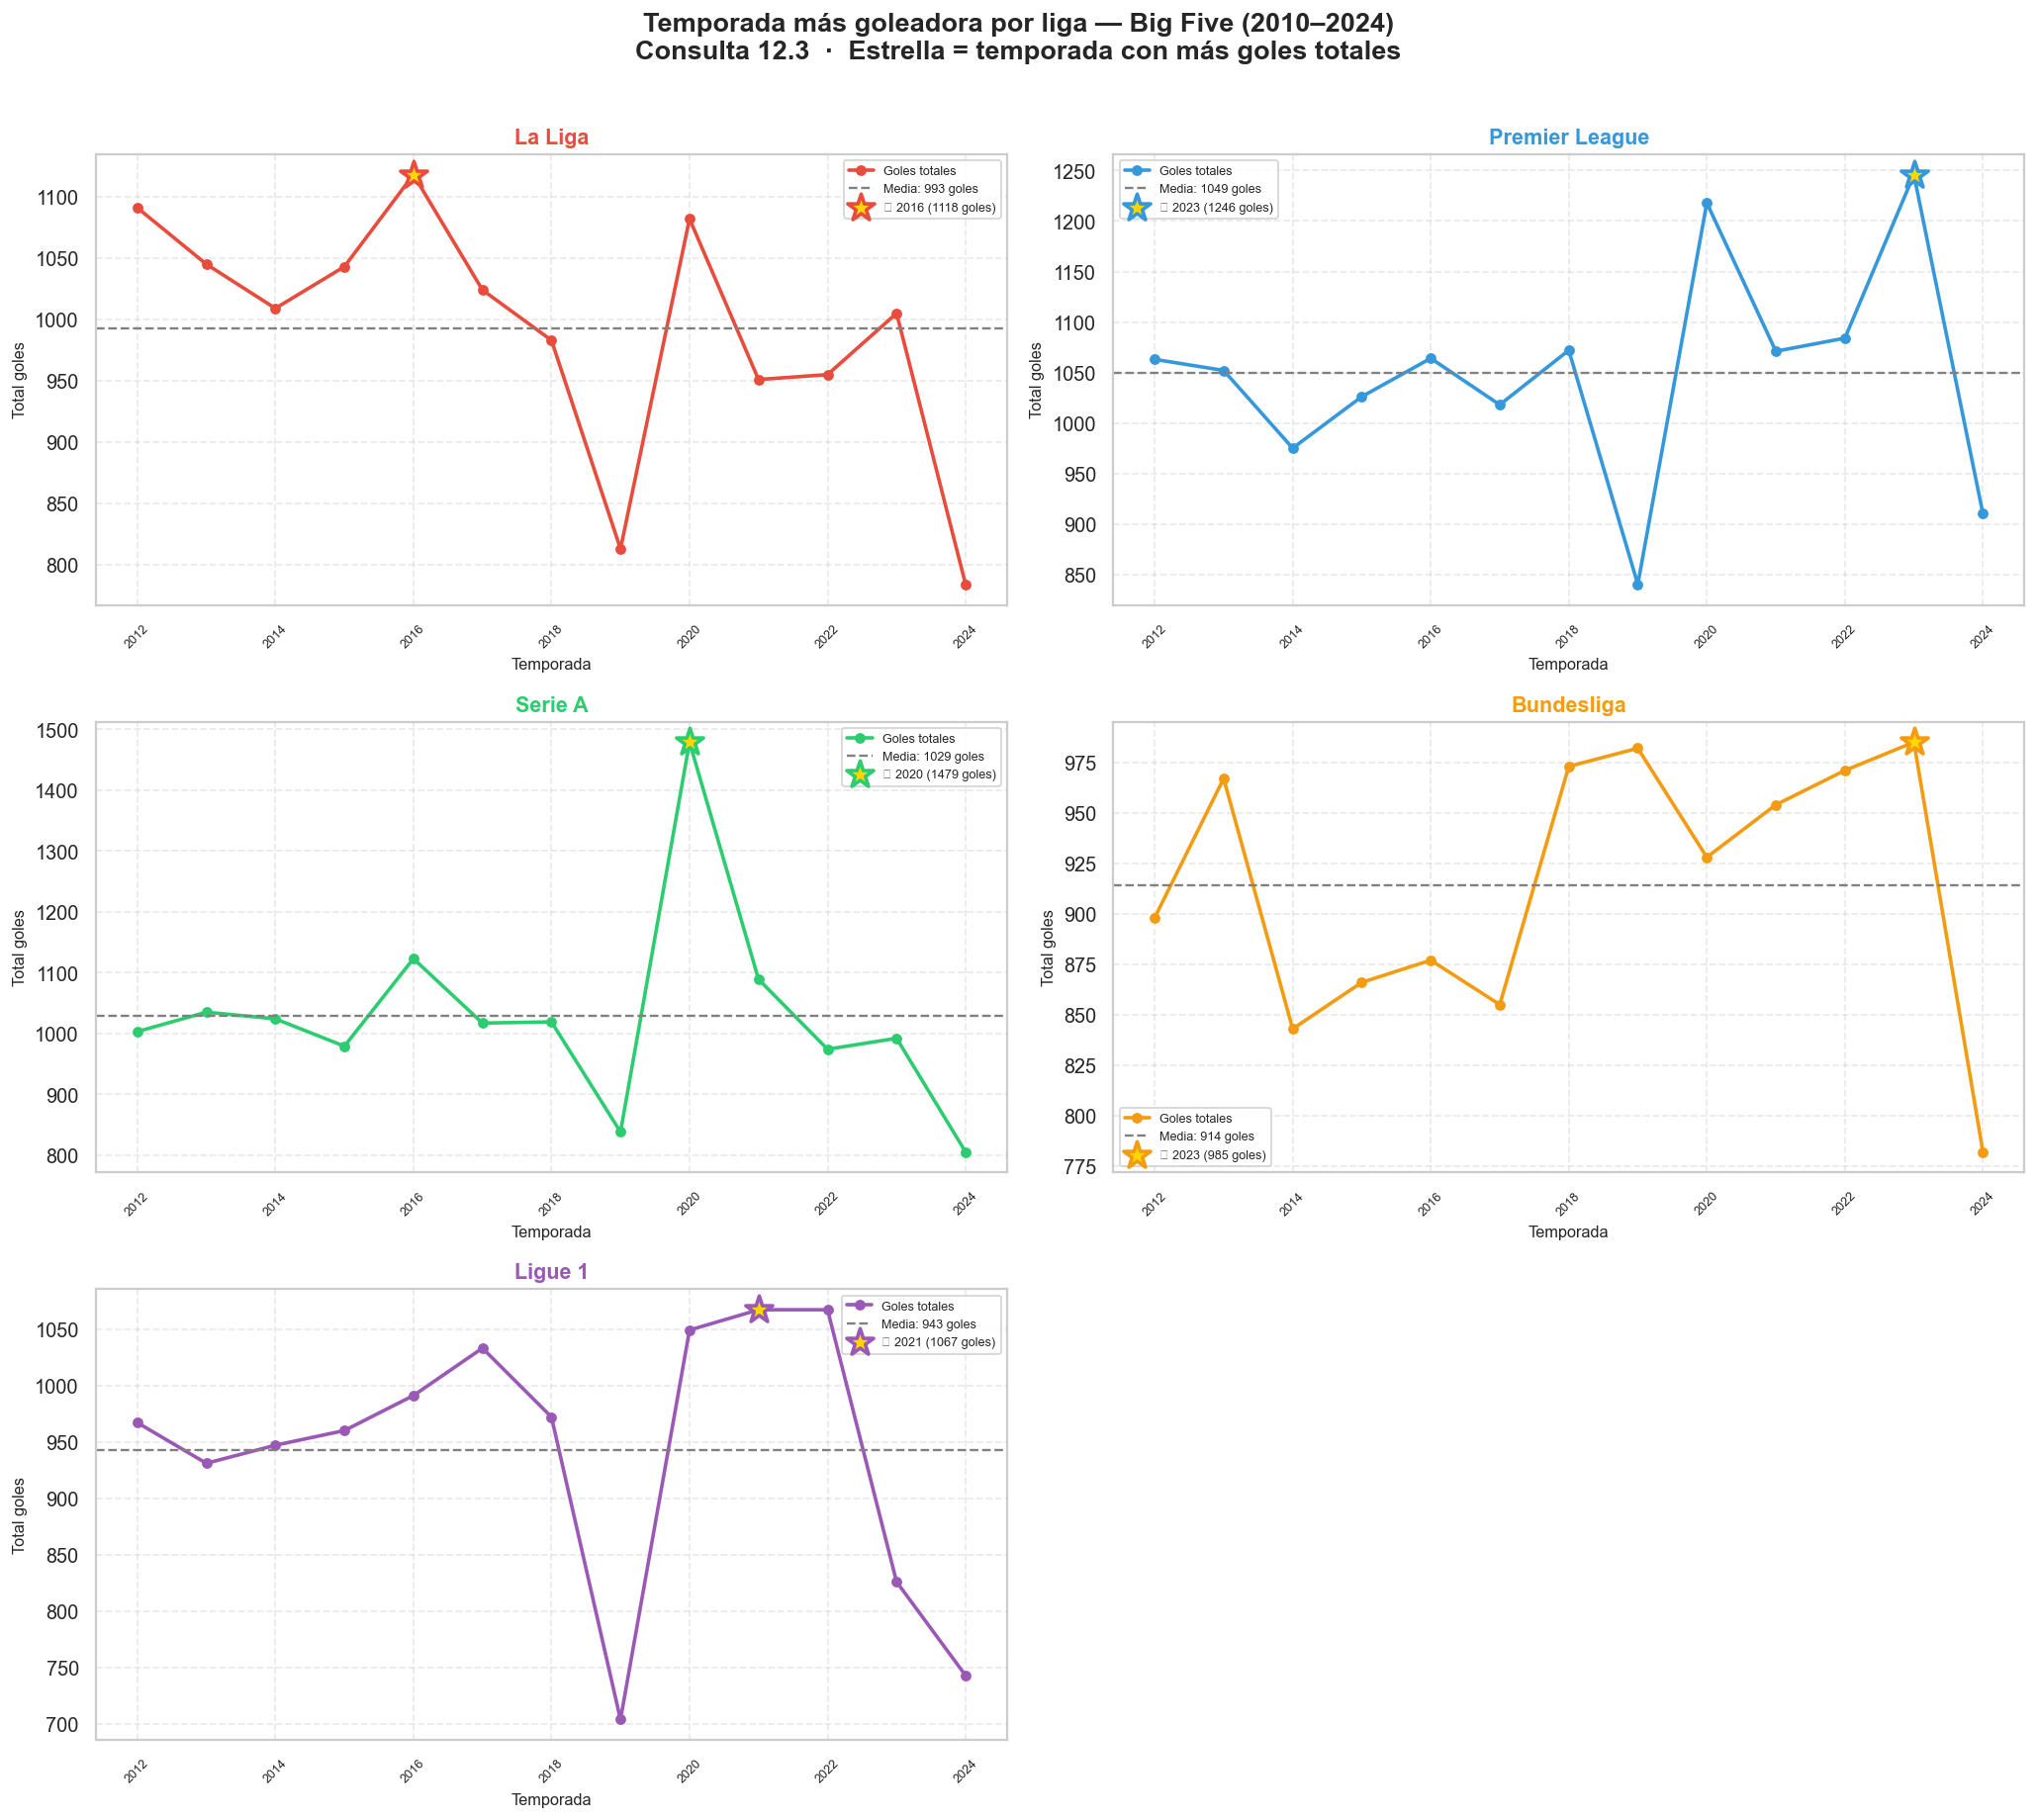

          liga  temporada  goles_totales  promedio_goles  partidos
    bundesliga       2023            985           3.219       306
        laliga       2016           1118           2.942       380
       ligue-1       2022           1067           2.808       380
premier-league       2023           1246           3.279       380
       serie-a       2020           1479           3.094       478


In [63]:

# ── Consulta 12.3 — SQL ORIGINAL de consultas_olap.sql ───────────────────────
SQL_GOLEADORA = """
WITH goles_por_temporada AS (
    SELECT
        comp.name                                                   AS liga,
        d.season_start_year                                         AS temporada,
        COUNT(*)                                                    AS partidos,
        SUM(fg.total_goals)                                         AS goles_totales,
        ROUND(AVG(fg.total_goals)::NUMERIC, 3)                      AS promedio_goles
    FROM dwh.fact_games fg
        INNER JOIN dwh.dim_date d          ON fg.date_id         = d.date_id
        INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
    WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
      AND d.season_start_year BETWEEN 2010 AND 2024
    GROUP BY comp.name, d.season_start_year
    HAVING COUNT(*) >= 30
)
SELECT
    liga,
    temporada,
    partidos,
    goles_totales,
    promedio_goles,
    ROUND(AVG(promedio_goles) OVER (PARTITION BY liga)::NUMERIC, 3)
                                                                    AS media_historica_liga,
    ROUND((promedio_goles - AVG(promedio_goles) OVER (PARTITION BY liga))::NUMERIC, 3)
                                                                    AS desv_vs_media,
    ROUND((promedio_goles - LAG(promedio_goles) OVER (PARTITION BY liga ORDER BY temporada))::NUMERIC, 3)
                                                                    AS variacion_vs_temporada_anterior,
    RANK() OVER (PARTITION BY liga ORDER BY promedio_goles DESC)    AS rk_temporada_goleadora,
    MAX(promedio_goles) OVER (PARTITION BY liga)                    AS max_historico,
    MIN(promedio_goles) OVER (PARTITION BY liga)                    AS min_historico
FROM goles_por_temporada
ORDER BY liga, temporada;
"""

df_gol = run_query(SQL_GOLEADORA)
for col in ['goles_totales', 'partidos', 'promedio_goles', 'media_historica_liga',
            'desv_vs_media', 'variacion_vs_temporada_anterior',
            'rk_temporada_goleadora', 'max_historico', 'min_historico']:
    df_gol[col] = pd.to_numeric(df_gol[col], errors='coerce')
df_gol['temporada'] = pd.to_numeric(df_gol['temporada'], errors='coerce').astype('Int64')

fig, axes = plt.subplots(3, 2, figsize=(16, 14), sharex=False)
axes = axes.flatten()
fig.suptitle(
    'Temporada más goleadora por liga — Big Five (2010–2024)\n'
    'Consulta 12.3  ·  Estrella = temporada con más goles totales',
    fontsize=15, fontweight='bold', y=1.01,
)

for i, liga_key in enumerate(LIGA_ORDER):
    ax  = axes[i]
    sub = df_gol[df_gol['liga'] == liga_key].sort_values('temporada')
    if sub.empty:
        ax.set_visible(False)
        continue

    color = LIGA_COLORS.get(liga_key, '#95a5a6')
    label = LIGA_LABELS.get(liga_key, liga_key)

    # Goles totales por temporada
    ax.plot(sub['temporada'], sub['goles_totales'],
            marker='o', linewidth=2, color=color, markersize=5, label='Goles totales')

    # Línea horizontal: media de goles totales histórica
    media_totales = float(sub['goles_totales'].mean())
    ax.axhline(media_totales, linestyle='--', color='grey',
               linewidth=1.3, label=f'Media: {media_totales:.0f} goles')

    # Estrella: temporada con más goles totales
    mejor = sub.nlargest(1, 'goles_totales')
    for _, row in mejor.iterrows():
        ax.scatter(row['temporada'], row['goles_totales'],
                   s=250, color='gold', edgecolors=color, linewidths=2,
                   zorder=5, marker='*',
                   label=f"★ {int(row['temporada'])} ({int(row['goles_totales'])} goles)")

    ax.set_title(label, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Temporada', fontsize=9)
    ax.set_ylabel('Total goles', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)

for j in range(len(LIGA_ORDER), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_fig('viz_09_temporada_goleadora.png')
plt.show()

mejor_por_liga = (df_gol.sort_values('goles_totales', ascending=False)
                  .groupby('liga').first().reset_index()
                  [['liga', 'temporada', 'goles_totales', 'promedio_goles',
                    'partidos']])
print(mejor_por_liga.to_string(index=False))


---
## 10. DICE + ROW_NUMBER — Top 25 partidos más espectaculares de la historia
**Consulta 12.4** · Tablas: `fact_games`, `dim_games`, `fact_game_events`, `dim_date`, `dim_competitions`

### ¿Qué hace la consulta?
Aplica `ROW_NUMBER() OVER (ORDER BY fg.total_goals DESC, fg.goal_difference DESC)` sobre todos los partidos de las Big Five para rankear los que más goles acumularon. El desempate secundario por `goal_difference` prioriza partidos desequilibrados (un 10-0 antes que un 5-5 con igual número de goles totales). Mediante `INNER JOIN` con `dim_games` se obtienen los nombres de los clubs local y visitante, y con `dim_date` la fecha formateada y la temporada. Un `LEFT JOIN` con `fact_game_events` agrega el conteo de **tarjetas** (`COUNT FILTER WHERE type='Cards'`) y **sustituciones** (`FILTER WHERE type='Substitutions'`). El `GROUP BY` completo asegura que el agregado de eventos colapse en una fila por partido.

- **`ROW_NUMBER` en lugar de `RANK`:** garantiza exactamente 25 filas únicas sin duplicados por empate
- **`LEFT JOIN fact_game_events`:** permite que partidos sin eventos registrados sigan apareciendo (con 0 tarjetas/sustituciones)
- **`GROUP BY game_id + resto de atributos`:** necesario porque el LEFT JOIN multiplica filas antes del agregado
- **`LIMIT 25`:** los 25 partidos con más goles totales en toda la historia del dataset

### ¿Cómo se visualiza?
Se genera una **tabla estilizada** con `matplotlib` (`ax.table`) sin ejes, que muestra 13 columnas: `#`, Liga, Temp., Local, GL, GV, Visitante, Total, Dif., Resultado, Tarj., Sust. y Fecha. La **cabecera** tiene fondo oscuro (`#2c3e50`) con texto blanco en negrita. El **color de fondo de cada fila** es una versión pastel del color de liga correspondiente, calculado diluyendo el color RGB con `color * 0.25 + 0.75`, lo que permite identificar visualmente a qué liga pertenece cada partido sin sobrecargar la tabla. La columna `liga` muestra el nombre legible (traducida con `LIGA_LABELS`), mientras que internamente se usa la clave lowercase para el cálculo de colores. La fecha, recibida como tipo `date` de PostgreSQL, se convierte en Python a string `DD/MM/YYYY` con `pd.to_datetime().dt.strftime`.

**Operación OLAP:** `DICE` (Big Five) + `WINDOW ROW_NUMBER` + agregación de eventos por partido


  ✓ Guardado: c:\Users\manuc\OneDrive\Escritorio\INFORMATICA\VISUAL_STUDIO_CODE\bbdd_avanzadas\DW-Transfermarkt_Dataset\Proyecto\etl\graficos\viz_10_partidos_espectaculares.png


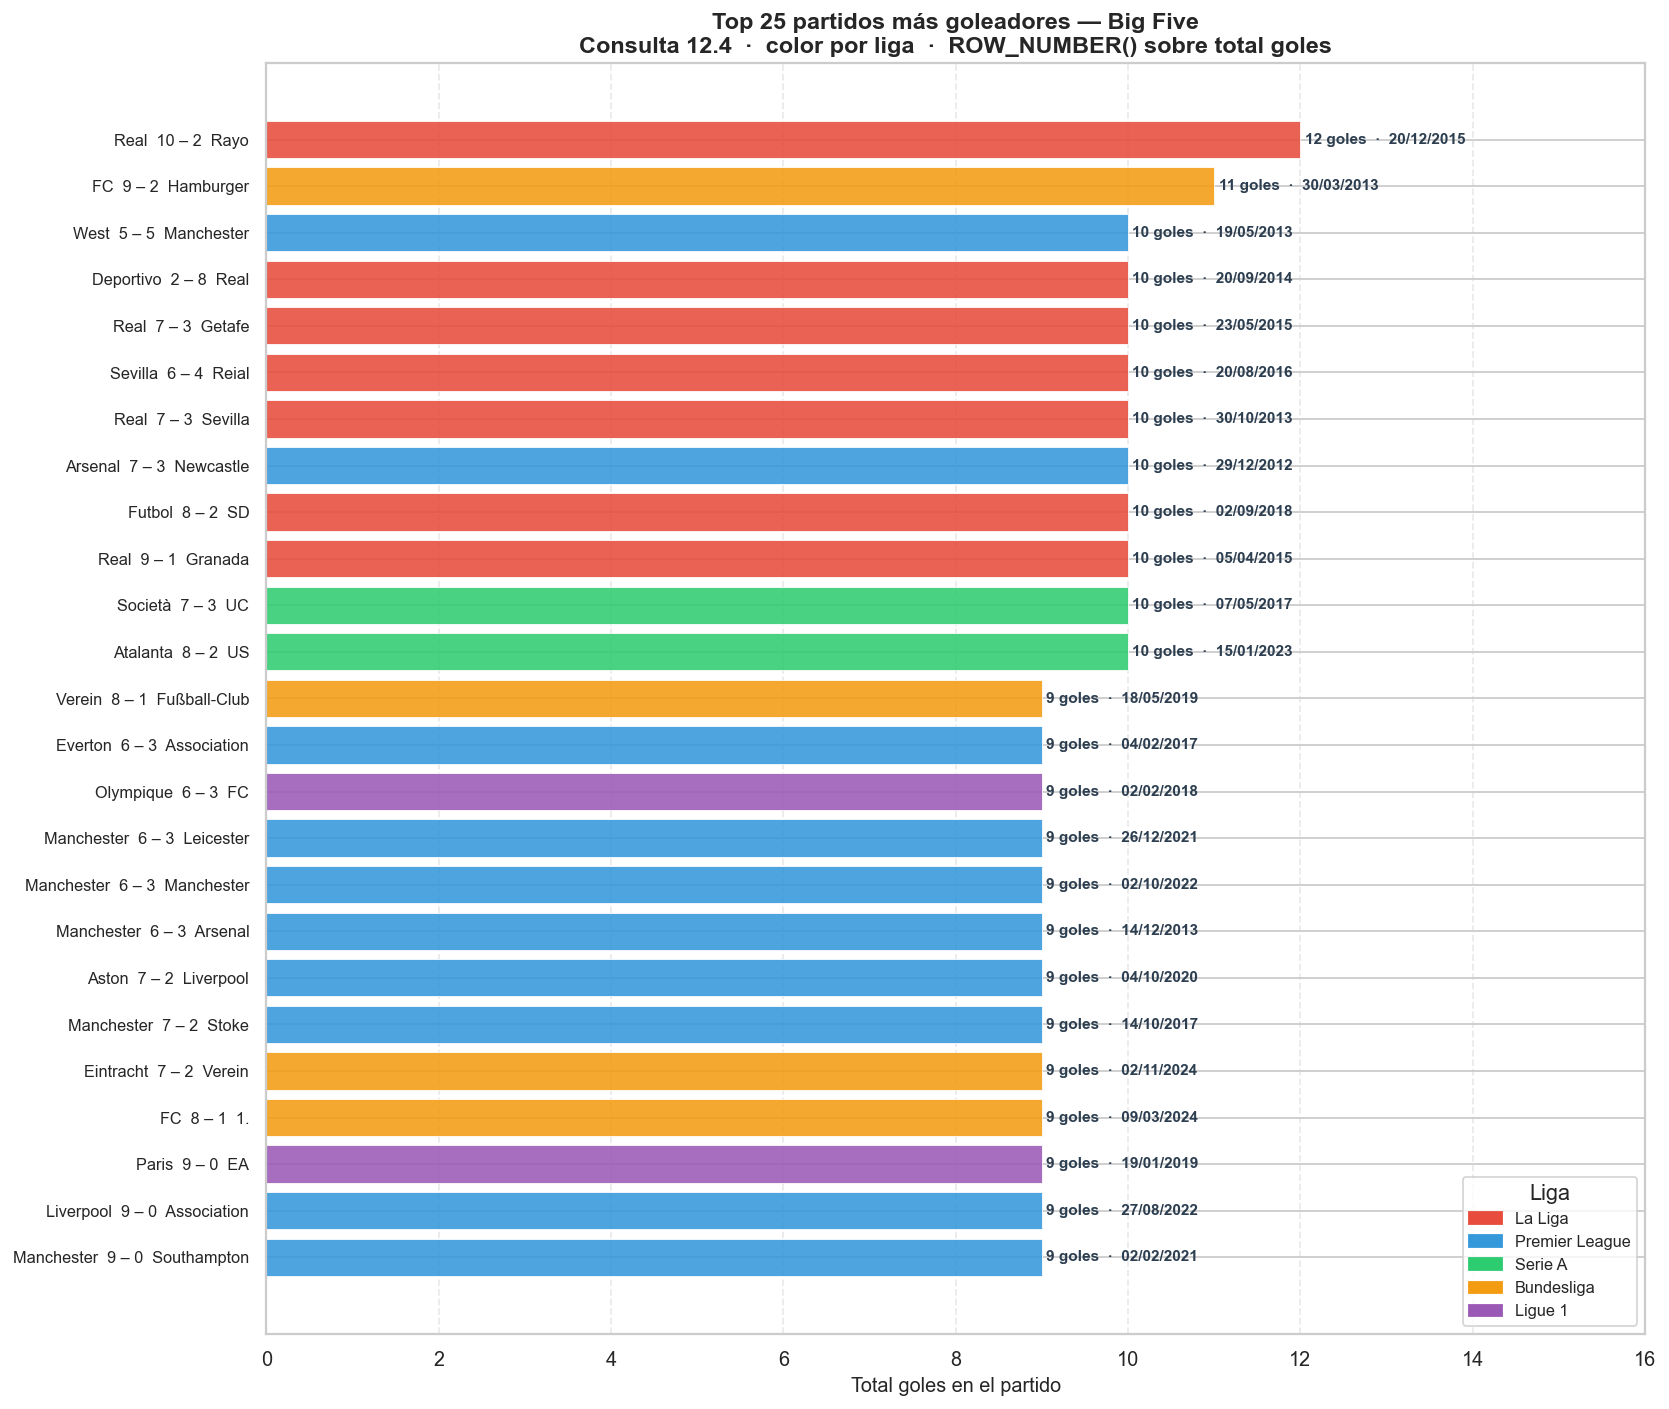

 ranking           liga  temporada                              local  goles_local  goles_visitante                                                visitante  total_goles  tarjetas_totales  sustituciones
       1         laliga       2015         Real Madrid Club de Fútbol           10                2                          Rayo Vallecano de Madrid S.A.D.           12                 6              6
       2     bundesliga       2012                  FC Bayern München            9                2                                             Hamburger SV           11                 0              6
       3         laliga       2014         Real Madrid Club de Fútbol            9                1                                               Granada CF           10                 3              6
       4        serie-a       2022  Atalanta Bergamasca Calcio S.p.a.            8                2                                      US Salernitana 1919           10                 1 

In [59]:

# ── Consulta 12.4 — SQL ORIGINAL de consultas_olap.sql ───────────────────────
SQL_ESPECTACULARES = """
SELECT
    ROW_NUMBER() OVER (ORDER BY fg.total_goals DESC, fg.goal_difference DESC)
                                                                    AS ranking,
    comp.name                                                       AS liga,
    d.full_date                                                     AS fecha,
    d.season_start_year                                             AS temporada,
    g.home_club_name                                                AS local,
    fg.home_club_goals                                              AS goles_local,
    fg.away_club_goals                                              AS goles_visitante,
    g.away_club_name                                                AS visitante,
    fg.total_goals                                                  AS total_goles,
    ABS(fg.goal_difference)                                         AS diferencia,
    CASE
        WHEN fg.is_home_win  THEN 'Victoria local'
        WHEN fg.is_away_win  THEN 'Victoria visitante'
        ELSE                      'Empate'
    END                                                             AS resultado,
    COUNT(ge.event_id) FILTER (WHERE ge.type = 'Cards')            AS tarjetas_totales,
    COUNT(ge.event_id) FILTER (WHERE ge.type = 'Substitutions')    AS sustituciones
FROM dwh.fact_games fg
    INNER JOIN dwh.dim_games        g    ON fg.game_id        = g.game_id
    INNER JOIN dwh.dim_date         d    ON fg.date_id        = d.date_id
    INNER JOIN dwh.dim_competitions comp ON fg.competition_id = comp.competition_id
    LEFT  JOIN dwh.fact_game_events ge   ON fg.game_id        = ge.game_id
WHERE fg.competition_id IN ('ES1','GB1','IT1','FR1','L1')
GROUP BY
    comp.name, d.full_date, d.season_start_year,
    g.home_club_name, g.away_club_name,
    fg.total_goals, fg.goal_difference, fg.home_club_goals,
    fg.away_club_goals, fg.is_home_win, fg.is_away_win, fg.is_draw,
    fg.game_id
ORDER BY fg.total_goals DESC, fg.goal_difference DESC
LIMIT 25;
"""

df_esp = run_query(SQL_ESPECTACULARES)
for col in ['goles_local', 'goles_visitante', 'total_goles', 'diferencia',
            'tarjetas_totales', 'sustituciones']:
    df_esp[col] = pd.to_numeric(df_esp[col], errors='coerce')
df_esp['fecha'] = pd.to_datetime(df_esp['fecha'], errors='coerce').dt.strftime('%d/%m/%Y')

# Etiqueta del partido: "Local X – Y Visitante"
df_esp['partido'] = (
    df_esp['local'].str.split().str[0] + '  ' +
    df_esp['goles_local'].astype(int).astype(str) + ' – ' +
    df_esp['goles_visitante'].astype(int).astype(str) + '  ' +
    df_esp['visitante'].str.split().str[0]
)

# Ordenar de más a menos goles (para que el top quede arriba)
df_esp_sorted = df_esp.sort_values('total_goles').reset_index(drop=True)

bar_colors = [LIGA_COLORS.get(l, '#95a5a6') for l in df_esp_sorted['liga']]

fig, ax = plt.subplots(figsize=(13, 11))
bars = ax.barh(
    df_esp_sorted['partido'], df_esp_sorted['total_goles'],
    color=bar_colors, edgecolor='white', linewidth=0.5, alpha=0.88
)

# Etiqueta con total goles + fecha al final de cada barra
for bar, row in zip(bars, df_esp_sorted.itertuples()):
    w = bar.get_width()
    ax.text(w + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{int(w)} goles  ·  {row.fecha}',
            va='center', ha='left', fontsize=8.5, color='#2c3e50', fontweight='bold')

# Leyenda de ligas
liga_handles = [mpatches.Patch(color=LIGA_COLORS[l], label=LIGA_LABELS[l])
                for l in LIGA_ORDER]
ax.legend(handles=liga_handles, loc='lower right', fontsize=9, title='Liga')

ax.set_xlabel('Total goles en el partido', fontsize=11)
ax.set_xlim(0, df_esp_sorted['total_goles'].max() + 4)
ax.set_title(
    'Top 25 partidos más goleadores — Big Five\n'
    'Consulta 12.4  ·  color por liga  ·  ROW_NUMBER() sobre total goles',
    fontsize=13, fontweight='bold',
)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
save_fig('viz_10_partidos_espectaculares.png')
plt.show()

print(df_esp[['ranking', 'liga', 'temporada', 'local', 'goles_local',
              'goles_visitante', 'visitante', 'total_goles',
              'tarjetas_totales', 'sustituciones']].to_string(index=False))
